### **Notebook #4**

# Group 2: Luca Milani, Marta Laskowska, Monika Kaczorowska
## EDA - Stock Price Data

### Libraries

In [92]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from datetime import timedelta
import math
import re
import requests
import bs4 as bs
import yfinance as yf
import datetime
from scipy.stats import norm
from collections import Counter


from ipywidgets import interact, IntSlider, Checkbox
from functools import lru_cache
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option('display.max_colwidth', None)

### Dataset Preparation

In [93]:
def load_excel_sheets_except_request_table(
    file_path: str,
    date_col: str = "Name",
    skip_sheets=("REQUEST_TABLE",)
) -> pd.DataFrame:
    """
    Read all sheets from an Excel file (except specific ones)
    and merge them on a shared key column (e.g. 'Name').

    Adds the sheet name to each column (e.g., 'HSBC - PRICE INDEX (Sheet1)').
    """

    # Read all sheets into a dict: {sheet_name: DataFrame}
    book = pd.read_excel(file_path, sheet_name=None, engine="openpyxl")

    frames = []
    for sheet_name, df in book.items():
        if sheet_name in skip_sheets or df.empty:
            continue

        # Skip if the key column is missing
        if date_col not in df.columns:
            continue

        df = df.copy()

        # Convert the merge key to datetime (if applicable)
        df[date_col] = pd.to_datetime(df[date_col], errors="ignore")

        # Rename columns to include the sheet name (except the merge key)
        df.columns = [
            col if col == date_col else f"{col.strip()} ({sheet_name})"
            for col in df.columns
        ]

        frames.append(df)

    if not frames:
        return pd.DataFrame()  # nothing usable

    # Merge all sheets on the key column (outer join to keep all rows)
    merged_df = frames[0]
    for other_df in frames[1:]:
        merged_df = pd.merge(
            merged_df,
            other_df,
            on=date_col,
            how="outer",
            suffixes=("", "_dup")
        )

    return merged_df

In [94]:
def get_excel_sheet_names(file_path: str, skip_sheets=("REQUEST_TABLE",)) -> list:
    """
    Return a list of sheet names in an Excel file, 
    excluding those specified in 'skip_sheets'.
    """
    # Create ExcelFile object (faster than reading full data)
    excel_book = pd.ExcelFile(file_path, engine="openpyxl")

    # Filter out any skipped sheets (case-insensitive match)
    sheet_names = [
        sheet for sheet in excel_book.sheet_names 
        if sheet not in skip_sheets
    ]

    return sheet_names

In [95]:
banks_ri = load_excel_sheets_except_request_table("banks_data_bocconi/banks_ri.xlsm")
display(banks_ri.head())

/var/folders/vp/3w5dj_l159g93tb2308ztr7r0000gn/T/ipykernel_53575/3591805812.py:28: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  df[date_col] = pd.to_datetime(df[date_col], errors="ignore")
/var/folders/vp/3w5dj_l159g93tb2308ztr7r0000gn/T/ipykernel_53575/3591805812.py:28: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  df[date_col] = pd.to_datetime(df[date_col], errors="ignore")
/var/folders/vp/3w5dj_l159g93tb2308ztr7r0000gn/T/ipykernel_53575/3591805812.py:28: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  df[date_col] = pd.to_datetime(df[date_col], errors="ignore")
/var/folders/vp/3w5dj_l159g93tb2308ztr7r0000gn/T/ipykernel_53575/3591805812.

,Name,AAREAL BANK - TOT RETURN IND (BD),COMDIRECT BANK - TOT RETURN IND (BD),COMMERZBANK - TOT RETURN IND (BD),DT.PFANDBRIEFBANK - TOT RETURN IND (BD),PROCREDIT HOLDING - TOT RETURN IND (BD),UMWELTBANK - TOT RETURN IND (BD),ALLIANZ - TOT RETURN IND (BD),DEUTSCHE BANK - TOT RETURN IND (BD),BANQUE NATIONALE DE BELGIQUE - TOT RETURN IND (BG),KBC ANCORA - TOT RETURN IND (BG),KBC GROUP - TOT RETURN IND (BG),BANK OF CYPRUS HOLDING - TOT RETURN IND (CP),HELLENIC BANK - TOT RETURN IND (CP),LHV GROUP - TOT RETURN IND (EO),BBV.ARGENTARIA - TOT RETURN IND (ES),BANCO DE SABADELL - TOT RETURN IND (ES),BANCO SANTANDER - TOT RETURN IND (ES),BANKIA - TOT RETURN IND (ES),BANKINTER 'R' - TOT RETURN IND (ES),CAIXABANK - TOT RETURN IND (ES),LIBERBANK - TOT RETURN IND (ES),UNICAJA BANCO - TOT RETURN IND (ES),AKTIA BANK A - TOT RETURN IND (FN),NORDEA BANK - TOT RETURN IND (FN),BNP PARIBAS - TOT RETURN IND (FR),CRCAM ILLE-VIL.CCI - TOT RETURN IND (FR),CRCAM NORD CCI - TOT RETURN IND (FR),CREDIT AGRICOLE - TOT RETURN IND (FR),CREDIT AGRICOLE BRIE PICARDIE - TOT RETURN IND (FR),CREDIT AGR.ILE DE FRANCE - TOT RETURN IND (FR),CREDIT FONCIER DE MONACO - TOT RETURN IND (FR),NATIXIS - TOT RETURN IND (FR),SOCIETE GENERALE - TOT RETURN IND (FR),BANQUE DE SAVOIE DEAD - 01/04/10 - TOT RETURN IND (FR),CREDIT AGRICOLE - TOT RETURN IND.1 (FR),MERSEN (EX LCL) - TOT RETURN IND (FR),ALPHA BANK - TOT RETURN IND (GR),ATTICA BANK - TOT RETURN IND (GR),BANK OF GREECE - TOT RETURN IND (GR),BANK OF PIRAEUS - TOT RETURN IND (GR),EUROBANK HOLDINGS - TOT RETURN IND (GR),NATIONAL BK.OF GREECE - TOT RETURN IND (GR),AIB GROUP - TOT RETURN IND (IR),BANK OF IRELAND GROUP - TOT RETURN IND (IR),PERMANENT TSB GHG. - TOT RETURN IND (IR),BANCA GENERALI - TOT RETURN IND (IT),BANCA MONTE DEI PASCHI - TOT RETURN IND (IT),BCA.PICCOLO CDT.VALTELL - TOT RETURN IND (IT),BANCA PPO.DI SONDRIO - TOT RETURN IND (IT),BANCO BPM - TOT RETURN IND (IT),BNC.DI DESIO E DELB. - TOT RETURN IND (IT),BPER BANCA - TOT RETURN IND (IT),CREDITO EMILIANO - TOT RETURN IND (IT),FINECOBANK SPA - TOT RETURN IND (IT),ILLIMITY BANK - TOT RETURN IND (IT),INTESA SANPAOLO - TOT RETURN IND (IT),UNICREDIT - TOT RETURN IND (IT),UNIONE DI BANCHE ITALIAN - TOT RETURN IND (IT),MEDIOBANCA BC.FIN - TOT RETURN IND (IT),SIAULIU BANKAS - TOT RETURN IND (LN),BANK OF VALLETTA - TOT RETURN IND (MA),FIMBANK - TOT RETURN IND (MA),HSBC BANK MALTA - TOT RETURN IND (MA),LOMBARD BANK - TOT RETURN IND (MA),ABN AMRO BANK - TOT RETURN IND (NL),ING GROEP - TOT RETURN IND (NL),NIBC HOLDING - TOT RETURN IND (NL),VAN LANSCHOT KEMPEN - TOT RETURN IND (NL),ASR NEDERLAND - TOT RETURN IND (NL),AEGON - TOT RETURN IND (NL),DELTA LLOYD GROUP DEAD - DEAD 01/06/17 - TOT RETURN IND (NL),BANK FUR TIROL UND VBG. - TOT RETURN IND (OE),BAWAG GROUP - TOT RETURN IND (OE),BKS BANK - TOT RETURN IND (OE),ERSTE GROUP BANK - TOT RETURN IND (OE),OBERBANK - TOT RETURN IND (OE),OBERBANK PREF. - TOT RETURN IND (OE),RAIFFEISEN BANK INTL. - TOT RETURN IND (OE),BANCO COMR.PORTUGUES 'R' - TOT RETURN IND (PT),NOVA LJUBLJANSKA BANK DD NPV - TOT RETURN IND (SJ),OTP BANKA SLOVENSKO - TOT RETURN IND (SX),OTP BANKA SLOVENSKO2 - TOT RETURN IND (SX),OTP BANKA SLOVENSKO3 - TOT RETURN IND (SX),TATRA BANKA - TOT RETURN IND (SX),TATRA BANKA 2 - TOT RETURN IND (SX),VSEOBECNA UVEROVA BANKA - TOT RETURN IND (SX),BANK OF AMERICA - TOT RETURN IND (US),TRUIST FINANCIAL - TOT RETURN IND (US),BOK FINL. - TOT RETURN IND (US),CIT GROUP - TOT RETURN IND (US),CITIZENS FINANCIAL GROUP - TOT RETURN IND (US),COMERICA - TOT RETURN IND (US),COMMERCE BCSH. - TOT RETURN IND (US),CREDICORP - TOT RETURN IND (US),CULLEN FO.BANKERS - TOT RETURN IND (US),DISCOVER FINANCIAL SVS. - TOT RETURN IND (US),EAST WEST BANCORP - TOT RETURN IND (US),FIFTH THIRD BANCORP - TOT RETURN IND (US),FIRST CTZN.BCSH.A - TOT RETURN IND (US),FIRST FINL.BKSH. - TOT RETURN IND (US),FIRST HORIZON NATIONAL - TOT RETURN IND (US),FIRST REPUBLIC BANK - TOT RETURN IND (US),FNB - TOT RETURN IND (US),HUNTINGTON BCSH. - TOT RETURN IND (US),IBE

In [96]:
missing_summary = pd.DataFrame({
    "Missing Values": banks_ri.isnull().sum(),
    "Percent Missing (%)": (banks_ri.isnull().mean() * 100).round(2)
}).sort_values(by="Percent Missing (%)", ascending=False)
print(len(missing_summary))
missing_summary.head()

159


,Missing Values,Percent Missing (%)
ILLIMITY BANK - TOT RETURN IND (IT),2915,90.64
NOVA LJUBLJANSKA BANK DD NPV - TOT RETURN IND (SJ),2836,88.18
OTP BANKA SLOVENSKO3 - TOT RETURN IND (SX),2791,86.78
TRISTATE CAPITAL HOLDINGS DS - TOT RETURN IND (US),2669,82.99
NIBC HOLDING - TOT RETURN IND (NL),2668,82.96


In [97]:
bank_ri_scand = load_excel_sheets_except_request_table("banks_data_bocconi/scandinavian_banks_ri.xlsm")
display(bank_ri_scand.head())

/var/folders/vp/3w5dj_l159g93tb2308ztr7r0000gn/T/ipykernel_53575/3591805812.py:28: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  df[date_col] = pd.to_datetime(df[date_col], errors="ignore")
/var/folders/vp/3w5dj_l159g93tb2308ztr7r0000gn/T/ipykernel_53575/3591805812.py:28: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  df[date_col] = pd.to_datetime(df[date_col], errors="ignore")
/var/folders/vp/3w5dj_l159g93tb2308ztr7r0000gn/T/ipykernel_53575/3591805812.py:28: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  df[date_col] = pd.to_datetime(df[date_col], errors="ignore")


,Name,BANQUE CANTON.DE GENEVE - TOT RETURN IND (SW),BANQUE CANTONALE VAUDOISE - TOT RETURN IND (SW),BASELLANDSCHAFTLICH E KANTONALBANK - TOT RETURN IND (SW),BERNER KANTONALBANK - TOT RETURN IND (SW),CEMBRA MONEY BANK N ORD - TOT RETURN IND (SW),EFG INTERNATIONAL N - TOT RETURN IND (SW),GRAUB KB 'P' - TOT RETURN IND (SW),LIECHTENSTEINISCHE LANDESBANK - TOT RETURN IND (SW),LUZERNER KANTONALBANK - TOT RETURN IND (SW),SCHWEIZERISCHE NAT.BK. - TOT RETURN IND (SW),ST GALLER KANTONALBANK - TOT RETURN IND (SW),THURGAUER KANTONALBANK - TOT RETURN IND (SW),VALIANT 'R' - TOT RETURN IND (SW),VONTOBEL HOLDING - TOT RETURN IND (SW),VP BANK - TOT RETURN IND (SW),WALLISER KANTONALBANK - TOT RETURN IND (SW),ZUGER KANTONALBANK - TOT RETURN IND (SW),DNB - TOT RETURN IND (NW),MYBANK - TOT RETURN IND (NW),NORWEGIAN FINANS HOLDING - TOT RETURN IND (NW),SPAREBANK 1 OSTLANDET - TOT RETURN IND (NW),SPAREBANK 1 SMN ORDS - TOT RETURN IND (NW),SPAREBANK 1 SR-BANK - TOT RETURN IND (NW),AVANZA BANK HOLDING - TOT RETURN IND (SD),SKANDINAVISKA ENSKILDA BANKEN A - TOT RETURN IND (SD),SVENSKA HANDELSBANKEN A - TOT RETURN IND (SD),SWEDBANK A - TOT RETURN IND (SD)
0,2008-01-01,112.58,588.28,821.00,211.61,NaN,115.53,823.96,436.23,549.11,504.42,386.38,NaN,545.87,330.42,1055.58,253.42,417.08,1755.09,NaN,NaN,NaN,1038.09,1345.10,2221.74,4647.10,7051.14,718.48
1,2008-01-02,112.58,588.28,821.09,211.61,NaN,115.53,824.05,436.23,549.11,504.42,386.38,NaN,545.87,330.42,1055.72,253.42,417.08,1776.23,NaN,NaN,NaN,1041.68,1340.02,2242.24,4604.98,6983.02,714.55
2,2008-01-03,111.39,577.42,822.03,211.61,NaN,112.74,829.13,429.43,544.92,504.42,387.55,NaN,545.87,319.86,1021.02,253.42,413.35,1738.17,NaN,NaN,NaN,1048.86,1329.87,2229.94,4647.10,6914.89,716.52
3,2008-01-04,111.39,565.97,822.12,212.61,NaN,103.85,834.21,429.65,542.30,504.42,376.30,NaN,545.25,313.52,989.14,251.86,414.59,1721.26,NaN,NaN,NaN,1052.46,1340.02,2127.46,4534.79,6795.66,696.89
4,2008-01-07,112.58,541.31,822.21,211.12,NaN,92.81,829.30,418.69,541.78,504.42,369.70,NaN,546.49,300.25,990.23,253.68,418.33,1721.26,NaN,NaN,NaN,1041.68,1314.64,2045.48,4506.71,6846.76,692.96


In [98]:
missing_summary_scand = pd.DataFrame({
    "Missing Values": bank_ri_scand.isnull().sum(),
    "Percent Missing (%)": (bank_ri_scand.isnull().mean() * 100).round(2)
}).sort_values(by="Percent Missing (%)", ascending=False)

missing_summary_scand.head()

,Missing Values,Percent Missing (%)
SPAREBANK 1 OSTLANDET - TOT RETURN IND (NW),2465,73.30
MYBANK - TOT RETURN IND (NW),2368,70.41
NORWEGIAN FINANS HOLDING - TOT RETURN IND (NW),2208,65.66
THURGAUER KANTONALBANK - TOT RETURN IND (SW),1634,48.59
CEMBRA MONEY BANK N ORD - TOT RETURN IND (SW),1521,45.23


In [99]:
banks_pi = load_excel_sheets_except_request_table("banks_data_bocconi/banks_pi.xlsm")
display(banks_pi.head())

/var/folders/vp/3w5dj_l159g93tb2308ztr7r0000gn/T/ipykernel_53575/3591805812.py:28: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  df[date_col] = pd.to_datetime(df[date_col], errors="ignore")
/var/folders/vp/3w5dj_l159g93tb2308ztr7r0000gn/T/ipykernel_53575/3591805812.py:28: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  df[date_col] = pd.to_datetime(df[date_col], errors="ignore")
/var/folders/vp/3w5dj_l159g93tb2308ztr7r0000gn/T/ipykernel_53575/3591805812.py:28: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  df[date_col] = pd.to_datetime(df[date_col], errors="ignore")
/var/folders/vp/3w5dj_l159g93tb2308ztr7r0000gn/T/ipykernel_53575/3591805812.

,Name,AAREAL BANK - PRICE INDEX (BD),COMDIRECT BANK - PRICE INDEX (BD),COMMERZBANK - PRICE INDEX (BD),DT.PFANDBRIEFBANK - PRICE INDEX (BD),PROCREDIT HOLDING - PRICE INDEX (BD),UMWELTBANK - PRICE INDEX (BD),ALLIANZ - PRICE INDEX (BD),DEUTSCHE BANK - PRICE INDEX (BD),BANQUE NATIONALE DE BELGIQUE - PRICE INDEX (BG),KBC ANCORA - PRICE INDEX (BG),KBC GROUP - PRICE INDEX (BG),BANK OF CYPRUS HOLDING - PRICE INDEX (CP),HELLENIC BANK - PRICE INDEX (CP),LHV GROUP - PRICE INDEX (EO),BBV.ARGENTARIA - PRICE INDEX (ES),BANCO DE SABADELL - PRICE INDEX (ES),BANCO SANTANDER - PRICE INDEX (ES),BANKIA - PRICE INDEX (ES),BANKINTER 'R' - PRICE INDEX (ES),CAIXABANK - PRICE INDEX (ES),LIBERBANK - PRICE INDEX (ES),UNICAJA BANCO - PRICE INDEX (ES),AKTIA BANK A - PRICE INDEX (FN),NORDEA BANK - PRICE INDEX (FN),BNP PARIBAS - PRICE INDEX (FR),CRCAM ILLE-VIL.CCI - PRICE INDEX (FR),CRCAM NORD CCI - PRICE INDEX (FR),CREDIT AGRICOLE - PRICE INDEX (FR),CREDIT AGRICOLE BRIE PICARDIE - PRICE INDEX (FR),CREDIT AGR.ILE DE FRANCE - PRICE INDEX (FR),CREDIT FONCIER DE MONACO - PRICE INDEX (FR),NATIXIS - PRICE INDEX (FR),SOCIETE GENERALE - PRICE INDEX (FR),BANQUE DE SAVOIE DEAD - 01/04/10 - PRICE INDEX (FR),CREDIT AGRICOLE - PRICE INDEX.1 (FR),MERSEN (EX LCL) - PRICE INDEX (FR),ALPHA BANK - PRICE INDEX (GR),ATTICA BANK - PRICE INDEX (GR),BANK OF GREECE - PRICE INDEX (GR),BANK OF PIRAEUS - PRICE INDEX (GR),EUROBANK HOLDINGS - PRICE INDEX (GR),NATIONAL BK.OF GREECE - PRICE INDEX (GR),AIB GROUP - PRICE INDEX (IR),BANK OF IRELAND GROUP - PRICE INDEX (IR),PERMANENT TSB GHG. - PRICE INDEX (IR),BANCA GENERALI - PRICE INDEX (IT),BANCA MONTE DEI PASCHI - PRICE INDEX (IT),BCA.PICCOLO CDT.VALTELL - PRICE INDEX (IT),BANCA PPO.DI SONDRIO - PRICE INDEX (IT),BANCO BPM - PRICE INDEX (IT),BNC.DI DESIO E DELB. - PRICE INDEX (IT),BPER BANCA - PRICE INDEX (IT),CREDITO EMILIANO - PRICE INDEX (IT),FINECOBANK SPA - PRICE INDEX (IT),ILLIMITY BANK - PRICE INDEX (IT),INTESA SANPAOLO - PRICE INDEX (IT),UNICREDIT - PRICE INDEX (IT),UNIONE DI BANCHE ITALIAN - PRICE INDEX (IT),MEDIOBANCA BC.FIN - PRICE INDEX (IT),SIAULIU BANKAS - PRICE INDEX (LN),BANK OF VALLETTA - PRICE INDEX (MA),FIMBANK - PRICE INDEX (MA),HSBC BANK MALTA - PRICE INDEX (MA),LOMBARD BANK - PRICE INDEX (MA),ABN AMRO BANK - PRICE INDEX (NL),ING GROEP - PRICE INDEX (NL),NIBC HOLDING - PRICE INDEX (NL),VAN LANSCHOT KEMPEN - PRICE INDEX (NL),ASR NEDERLAND - PRICE INDEX (NL),AEGON - PRICE INDEX (NL),DELTA LLOYD GROUP DEAD - DEAD 01/06/17 - PRICE INDEX (NL),BANK FUR TIROL UND VBG. - PRICE INDEX (OE),BAWAG GROUP - PRICE INDEX (OE),BKS BANK - PRICE INDEX (OE),ERSTE GROUP BANK - PRICE INDEX (OE),OBERBANK - PRICE INDEX (OE),OBERBANK PREF. - PRICE INDEX (OE),RAIFFEISEN BANK INTL. - PRICE INDEX (OE),ERSTE GROUP BANK - PRICE INDEX.1 (OE),RAIFFEISEN BANK INTL. - PRICE INDEX.1 (OE),VOLKSBANK VBG.PARTN. - PRICE INDEX (OE),BANCO COMR.PORTUGUES 'R' - PRICE INDEX (PT),NOVA LJUBLJANSKA BANK DD NPV - PRICE INDEX (SJ),OTP BANKA SLOVENSKO - PRICE INDEX (SX),OTP BANKA SLOVENSKO2 - PRICE INDEX (SX),OTP BANKA SLOVENSKO3 - PRICE INDEX (SX),TATRA BANKA - PRICE INDEX (SX),TATRA BANKA 2 - PRICE INDEX (SX),VSEOBECNA UVEROVA BANKA - PRICE INDEX (SX),BANK OF AMERICA - PRICE INDEX (US),TRUIST FINANCIAL - PRICE INDEX (US),BOK FINL. - PRICE INDEX (US),CIT GROUP - PRICE INDEX (US),CITIZENS FINANCIAL GROUP - PRICE INDEX (US),COMERICA - PRICE INDEX (US),COMMERCE BCSH. - PRICE INDEX (US),CREDICORP - PRICE INDEX (US),CULLEN FO.BANKERS - PRICE INDEX (US),DISCOVER FINANCIAL SVS. - PRICE INDEX (US),EAST WEST BANCORP - PRICE INDEX (US),FIFTH THIRD BANCORP - PRICE INDEX (US),FIRST CTZN.BCSH.A - PRICE INDEX (US),FIRST FINL.BKSH. - PRICE INDEX (US),FIRST HORIZON NATIONAL - PRICE INDEX (US),FIRST REPUBLIC BANK - PRICE INDEX (US),FNB - PRICE INDEX (US),HUNTINGTON BCSH. - PRICE INDEX (US),IBERIABANK - PRICE INDEX (US),KEYCORP - PRICE INDEX (US),M&T BANK - PRICE INDEX (US),NEW YORK COMMUNITY BANCORP - PRICE INDEX (US),PACWEST BANCORP - PRICE INDEX (US),PEOPLES UNITED FINANCIAL - P

In [100]:
missing_summary_pi = pd.DataFrame({
    "Missing Values": banks_pi.isnull().sum(),
    "Percent Missing (%)": (banks_pi.isnull().mean() * 100).round(2)
}).sort_values(by="Percent Missing (%)", ascending=False)

print(len(missing_summary_pi))
missing_summary_pi.head()


161


,Missing Values,Percent Missing (%)
ILLIMITY BANK - PRICE INDEX (IT),2915,90.64
NOVA LJUBLJANSKA BANK DD NPV - PRICE INDEX (SJ),2836,88.18
OTP BANKA SLOVENSKO3 - PRICE INDEX (SX),2791,86.78
TRISTATE CAPITAL HOLDINGS DS - PRICE INDEX (US),2669,82.99
NIBC HOLDING - PRICE INDEX (NL),2668,82.96


Percentage Change using Price Index:

In [101]:
def pct_from_price(df_price):
    df_price = df_price.apply(pd.to_numeric, errors="coerce")
    prev = df_price.shift(1)
    pct = (df_price / prev) - 1
    pct[prev == 0] = np.nan   # avoid ∞
    return pct

In [102]:
cols_to_change = [col for col in banks_pi.columns if col.lower() != "name"]

# Compute percentage change only for numeric columns (excluding 'Name')
banks_pi_pct = pct_from_price(banks_pi[cols_to_change])

# Rename columns:
new_cols = []
for col in cols_to_change:
    if "PRICE INDEX" in col.upper():
        new_cols.append(col.replace("PRICE INDEX", "PCT_CHANGE").strip())
    else:
        new_cols.append(f"{col} - PCT_CHANGE")

banks_pi_pct.columns = new_cols

# Combine original df (including 'Name') with percentage changes
banks_pi_combined = pd.concat([banks_pi, banks_pi_pct], axis=1)

# Display result
display(banks_pi_combined.head())

,Name,AAREAL BANK - PRICE INDEX (BD),COMDIRECT BANK - PRICE INDEX (BD),COMMERZBANK - PRICE INDEX (BD),DT.PFANDBRIEFBANK - PRICE INDEX (BD),PROCREDIT HOLDING - PRICE INDEX (BD),UMWELTBANK - PRICE INDEX (BD),ALLIANZ - PRICE INDEX (BD),DEUTSCHE BANK - PRICE INDEX (BD),BANQUE NATIONALE DE BELGIQUE - PRICE INDEX (BG),KBC ANCORA - PRICE INDEX (BG),KBC GROUP - PRICE INDEX (BG),BANK OF CYPRUS HOLDING - PRICE INDEX (CP),HELLENIC BANK - PRICE INDEX (CP),LHV GROUP - PRICE INDEX (EO),BBV.ARGENTARIA - PRICE INDEX (ES),BANCO DE SABADELL - PRICE INDEX (ES),BANCO SANTANDER - PRICE INDEX (ES),BANKIA - PRICE INDEX (ES),BANKINTER 'R' - PRICE INDEX (ES),CAIXABANK - PRICE INDEX (ES),LIBERBANK - PRICE INDEX (ES),UNICAJA BANCO - PRICE INDEX (ES),AKTIA BANK A - PRICE INDEX (FN),NORDEA BANK - PRICE INDEX (FN),BNP PARIBAS - PRICE INDEX (FR),CRCAM ILLE-VIL.CCI - PRICE INDEX (FR),CRCAM NORD CCI - PRICE INDEX (FR),CREDIT AGRICOLE - PRICE INDEX (FR),CREDIT AGRICOLE BRIE PICARDIE - PRICE INDEX (FR),CREDIT AGR.ILE DE FRANCE - PRICE INDEX (FR),CREDIT FONCIER DE MONACO - PRICE INDEX (FR),NATIXIS - PRICE INDEX (FR),SOCIETE GENERALE - PRICE INDEX (FR),BANQUE DE SAVOIE DEAD - 01/04/10 - PRICE INDEX (FR),CREDIT AGRICOLE - PRICE INDEX.1 (FR),MERSEN (EX LCL) - PRICE INDEX (FR),ALPHA BANK - PRICE INDEX (GR),ATTICA BANK - PRICE INDEX (GR),BANK OF GREECE - PRICE INDEX (GR),BANK OF PIRAEUS - PRICE INDEX (GR),EUROBANK HOLDINGS - PRICE INDEX (GR),NATIONAL BK.OF GREECE - PRICE INDEX (GR),AIB GROUP - PRICE INDEX (IR),BANK OF IRELAND GROUP - PRICE INDEX (IR),PERMANENT TSB GHG. - PRICE INDEX (IR),BANCA GENERALI - PRICE INDEX (IT),BANCA MONTE DEI PASCHI - PRICE INDEX (IT),BCA.PICCOLO CDT.VALTELL - PRICE INDEX (IT),BANCA PPO.DI SONDRIO - PRICE INDEX (IT),BANCO BPM - PRICE INDEX (IT),BNC.DI DESIO E DELB. - PRICE INDEX (IT),BPER BANCA - PRICE INDEX (IT),CREDITO EMILIANO - PRICE INDEX (IT),FINECOBANK SPA - PRICE INDEX (IT),ILLIMITY BANK - PRICE INDEX (IT),INTESA SANPAOLO - PRICE INDEX (IT),UNICREDIT - PRICE INDEX (IT),UNIONE DI BANCHE ITALIAN - PRICE INDEX (IT),MEDIOBANCA BC.FIN - PRICE INDEX (IT),SIAULIU BANKAS - PRICE INDEX (LN),BANK OF VALLETTA - PRICE INDEX (MA),FIMBANK - PRICE INDEX (MA),HSBC BANK MALTA - PRICE INDEX (MA),LOMBARD BANK - PRICE INDEX (MA),ABN AMRO BANK - PRICE INDEX (NL),ING GROEP - PRICE INDEX (NL),NIBC HOLDING - PRICE INDEX (NL),VAN LANSCHOT KEMPEN - PRICE INDEX (NL),ASR NEDERLAND - PRICE INDEX (NL),AEGON - PRICE INDEX (NL),DELTA LLOYD GROUP DEAD - DEAD 01/06/17 - PRICE INDEX (NL),BANK FUR TIROL UND VBG. - PRICE INDEX (OE),BAWAG GROUP - PRICE INDEX (OE),BKS BANK - PRICE INDEX (OE),ERSTE GROUP BANK - PRICE INDEX (OE),OBERBANK - PRICE INDEX (OE),OBERBANK PREF. - PRICE INDEX (OE),RAIFFEISEN BANK INTL. - PRICE INDEX (OE),ERSTE GROUP BANK - PRICE INDEX.1 (OE),RAIFFEISEN BANK INTL. - PRICE INDEX.1 (OE),VOLKSBANK VBG.PARTN. - PRICE INDEX (OE),BANCO COMR.PORTUGUES 'R' - PRICE INDEX (PT),NOVA LJUBLJANSKA BANK DD NPV - PRICE INDEX (SJ),OTP BANKA SLOVENSKO - PRICE INDEX (SX),OTP BANKA SLOVENSKO2 - PRICE INDEX (SX),OTP BANKA SLOVENSKO3 - PRICE INDEX (SX),TATRA BANKA - PRICE INDEX (SX),TATRA BANKA 2 - PRICE INDEX (SX),VSEOBECNA UVEROVA BANKA - PRICE INDEX (SX),BANK OF AMERICA - PRICE INDEX (US),TRUIST FINANCIAL - PRICE INDEX (US),BOK FINL. - PRICE INDEX (US),CIT GROUP - PRICE INDEX (US),CITIZENS FINANCIAL GROUP - PRICE INDEX (US),COMERICA - PRICE INDEX (US),COMMERCE BCSH. - PRICE INDEX (US),CREDICORP - PRICE INDEX (US),CULLEN FO.BANKERS - PRICE INDEX (US),DISCOVER FINANCIAL SVS. - PRICE INDEX (US),EAST WEST BANCORP - PRICE INDEX (US),FIFTH THIRD BANCORP - PRICE INDEX (US),FIRST CTZN.BCSH.A - PRICE INDEX (US),FIRST FINL.BKSH. - PRICE INDEX (US),FIRST HORIZON NATIONAL - PRICE INDEX (US),FIRST REPUBLIC BANK - PRICE INDEX (US),FNB - PRICE INDEX (US),HUNTINGTON BCSH. - PRICE INDEX (US),IBERIABANK - PRICE INDEX (US),KEYCORP - PRICE INDEX (US),M&T BANK - PRICE INDEX (US),NEW YORK COMMUNITY BANCORP - PRICE INDEX (US),PACWEST BANCORP - PRICE INDEX (US),PEOPLES UNITED FINANCIAL - P

In [103]:
sheet_list = get_excel_sheet_names("banks_data_bocconi/banks_pi.xlsm")
print(sheet_list)

['BD', 'BG', 'CP', 'EO', 'ES', 'FN', 'FR', 'GR', 'IR', 'IT', 'LN', 'MA', 'NL', 'OE', 'PT', 'SJ', 'SX', 'US', 'UK']


In [104]:
bank_pi_scand = load_excel_sheets_except_request_table("banks_data_bocconi/scandinavian_banks_pi.xlsm")
display(bank_pi_scand.head())

/var/folders/vp/3w5dj_l159g93tb2308ztr7r0000gn/T/ipykernel_53575/3591805812.py:28: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  df[date_col] = pd.to_datetime(df[date_col], errors="ignore")
/var/folders/vp/3w5dj_l159g93tb2308ztr7r0000gn/T/ipykernel_53575/3591805812.py:28: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  df[date_col] = pd.to_datetime(df[date_col], errors="ignore")
/var/folders/vp/3w5dj_l159g93tb2308ztr7r0000gn/T/ipykernel_53575/3591805812.py:28: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  df[date_col] = pd.to_datetime(df[date_col], errors="ignore")


,Name,BANQUE CANTON.DE GENEVE - PRICE INDEX (SW),BANQUE CANTONALE VAUDOISE - PRICE INDEX (SW),BASELLANDSCHAFTLICH E KANTONALBANK - PRICE INDEX (SW),BERNER KANTONALBANK - PRICE INDEX (SW),CEMBRA MONEY BANK N ORD - PRICE INDEX (SW),EFG INTERNATIONAL N - PRICE INDEX (SW),GRAUB KB 'P' - PRICE INDEX (SW),LIECHTENSTEINISCHE LANDESBANK - PRICE INDEX (SW),LUZERNER KANTONALBANK - PRICE INDEX (SW),SCHWEIZERISCHE NAT.BK. - PRICE INDEX (SW),ST GALLER KANTONALBANK - PRICE INDEX (SW),THURGAUER KANTONALBANK - PRICE INDEX (SW),VALIANT 'R' - PRICE INDEX (SW),VONTOBEL HOLDING - PRICE INDEX (SW),VP BANK - PRICE INDEX (SW),WALLISER KANTONALBANK - PRICE INDEX (SW),ZUGER KANTONALBANK - PRICE INDEX (SW),DNB - PRICE INDEX (NW),MYBANK - PRICE INDEX (NW),NORWEGIAN FINANS HOLDING - PRICE INDEX (NW),SPAREBANK 1 OSTLANDET - PRICE INDEX (NW),SPAREBANK 1 SMN ORDS - PRICE INDEX (NW),SPAREBANK 1 SR-BANK - PRICE INDEX (NW),AVANZA BANK HOLDING - PRICE INDEX (SD),SKANDINAVISKA ENSKILDA BANKEN A - PRICE INDEX (SD),SVENSKA HANDELSBANKEN A - PRICE INDEX (SD),SWEDBANK A - PRICE INDEX (SD)
0,2008-01-01,85.4,229.4,404.9,186.4,NaN,114.9,431.8,274.5,268.3,243.5,327.2,NaN,473.0,190.1,642.7,154.6,211.7,830.0,NaN,NaN,NaN,418.3,517.9,1265.4,1747.7,3844.0,450.0
1,2008-01-02,85.4,229.4,404.9,186.4,NaN,114.9,431.8,274.5,268.3,243.5,327.2,NaN,473.0,190.1,642.7,154.6,211.7,840.0,NaN,NaN,NaN,419.7,515.9,1277.1,1731.8,3806.9,447.5
2,2008-01-03,84.4,225.1,405.3,186.4,NaN,112.1,434.4,270.2,266.2,243.5,328.2,NaN,473.0,184.1,621.5,154.6,209.8,822.0,NaN,NaN,NaN,422.6,512.0,1270.1,1747.7,3769.8,448.8
3,2008-01-04,84.4,220.7,405.3,187.3,NaN,103.3,437.0,270.4,265.0,243.5,318.7,NaN,472.4,180.4,602.0,153.7,210.5,814.0,NaN,NaN,NaN,424.1,515.9,1211.7,1705.4,3704.8,436.5
4,2008-01-07,85.4,211.0,405.3,186.0,NaN,92.3,434.4,263.5,264.7,243.5,313.1,NaN,473.5,172.8,602.6,154.8,212.3,814.0,NaN,NaN,NaN,419.7,506.1,1165.0,1694.9,3732.6,434.0


Percentage Change using Price Index:

In [105]:
cols_to_change = [col for col in bank_pi_scand.columns if col.lower() != "name"]

# Compute percentage change only for numeric columns (excluding 'Name')
banks_pi_pct = pct_from_price(bank_pi_scand[cols_to_change])

# Rename columns:
new_cols = []
for col in cols_to_change:
    if "PRICE INDEX" in col.upper():
        new_cols.append(col.replace("PRICE INDEX", "PCT_CHANGE").strip())
    else:
        new_cols.append(f"{col} - PCT_CHANGE")

banks_pi_pct.columns = new_cols

# Combine original df (including 'Name') with percentage changes
banks_pi_combined_scand = pd.concat([bank_pi_scand, banks_pi_pct], axis=1)

# Display result
display(banks_pi_combined_scand.head())

,Name,BANQUE CANTON.DE GENEVE - PRICE INDEX (SW),BANQUE CANTONALE VAUDOISE - PRICE INDEX (SW),BASELLANDSCHAFTLICH E KANTONALBANK - PRICE INDEX (SW),BERNER KANTONALBANK - PRICE INDEX (SW),CEMBRA MONEY BANK N ORD - PRICE INDEX (SW),EFG INTERNATIONAL N - PRICE INDEX (SW),GRAUB KB 'P' - PRICE INDEX (SW),LIECHTENSTEINISCHE LANDESBANK - PRICE INDEX (SW),LUZERNER KANTONALBANK - PRICE INDEX (SW),SCHWEIZERISCHE NAT.BK. - PRICE INDEX (SW),ST GALLER KANTONALBANK - PRICE INDEX (SW),THURGAUER KANTONALBANK - PRICE INDEX (SW),VALIANT 'R' - PRICE INDEX (SW),VONTOBEL HOLDING - PRICE INDEX (SW),VP BANK - PRICE INDEX (SW),WALLISER KANTONALBANK - PRICE INDEX (SW),ZUGER KANTONALBANK - PRICE INDEX (SW),DNB - PRICE INDEX (NW),MYBANK - PRICE INDEX (NW),NORWEGIAN FINANS HOLDING - PRICE INDEX (NW),SPAREBANK 1 OSTLANDET - PRICE INDEX (NW),SPAREBANK 1 SMN ORDS - PRICE INDEX (NW),SPAREBANK 1 SR-BANK - PRICE INDEX (NW),AVANZA BANK HOLDING - PRICE INDEX (SD),SKANDINAVISKA ENSKILDA BANKEN A - PRICE INDEX (SD),SVENSKA HANDELSBANKEN A - PRICE INDEX (SD),SWEDBANK A - PRICE INDEX (SD),BANQUE CANTON.DE GENEVE - PCT_CHANGE (SW),BANQUE CANTONALE VAUDOISE - PCT_CHANGE (SW),BASELLANDSCHAFTLICH E KANTONALBANK - PCT_CHANGE (SW),BERNER KANTONALBANK - PCT_CHANGE (SW),CEMBRA MONEY BANK N ORD - PCT_CHANGE (SW),EFG INTERNATIONAL N - PCT_CHANGE (SW),GRAUB KB 'P' - PCT_CHANGE (SW),LIECHTENSTEINISCHE LANDESBANK - PCT_CHANGE (SW),LUZERNER KANTONALBANK - PCT_CHANGE (SW),SCHWEIZERISCHE NAT.BK. - PCT_CHANGE (SW),ST GALLER KANTONALBANK - PCT_CHANGE (SW),THURGAUER KANTONALBANK - PCT_CHANGE (SW),VALIANT 'R' - PCT_CHANGE (SW),VONTOBEL HOLDING - PCT_CHANGE (SW),VP BANK - PCT_CHANGE (SW),WALLISER KANTONALBANK - PCT_CHANGE (SW),ZUGER KANTONALBANK - PCT_CHANGE (SW),DNB - PCT_CHANGE (NW),MYBANK - PCT_CHANGE (NW),NORWEGIAN FINANS HOLDING - PCT_CHANGE (NW),SPAREBANK 1 OSTLANDET - PCT_CHANGE (NW),SPAREBANK 1 SMN ORDS - PCT_CHANGE (NW),SPAREBANK 1 SR-BANK - PCT_CHANGE (NW),AVANZA BANK HOLDING - PCT_CHANGE (SD),SKANDINAVISKA ENSKILDA BANKEN A - PCT_CHANGE (SD),SVENSKA HANDELSBANKEN A - PCT_CHANGE (SD),SWEDBANK A - PCT_CHANGE (SD)
0,2008-01-01,85.4,229.4,404.9,186.4,NaN,114.9,431.8,274.5,268.3,243.5,327.2,NaN,473.0,190.1,642.7,154.6,211.7,830.0,NaN,NaN,NaN,418.3,517.9,1265.4,1747.7,3844.0,450.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2008-01-02,85.4,229.4,404.9,186.4,NaN,114.9,431.8,274.5,268.3,243.5,327.2,NaN,473.0,190.1,642.7,154.6,211.7,840.0,NaN,NaN,NaN,419.7,515.9,1277.1,1731.8,3806.9,447.5,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.012048,NaN,NaN,NaN,0.003347,-0.003862,0.009246,-0.009098,-0.009651,-0.005556
2,2008-01-03,84.4,225.1,405.3,186.4,NaN,112.1,434.4,270.2,266.2,243.5,328.2,NaN,473.0,184.1,621.5,154.6,209.8,822.0,NaN,NaN,NaN,422.6,512.0,1270.1,1747.7,3769.8,448.8,-0.011710,-0.018745,0.000988,0.000000,NaN,-0.024369,0.006021,-0.015665,-0.007827,0.0,0.003056,NaN,0.000000,-0.031562,-0.032986,0.000000,-0.008975,-0.021429,NaN,NaN,NaN,0.006910,-0.007560,-0.005481,0.009181,-0.009745,0.002905
3,2008-01-04,84.4,220.7,405.3,187.3,NaN,103.3,437.0,270.4,265.0,243.5,318.7,NaN,472.4,180.4,602.0,153.7,210.5,814.0,NaN,NaN,NaN,424.1,515.9,1211.7,1705.4,3704.8,436.5,0.000000,-0.019547,0.000000,0.004828,NaN,-0.078501,0.005985,0.000740,-0.004508,0.0,-0.028946,NaN,-0.001268,-0.020098,-0.031376,-0.005821,0.003337,-0.009732,NaN,NaN,NaN,0.003549,0.007617,-0.045981,-0.024203,-0.017242,-0.027406
4,2008-01-07,85.4,211.0,405.3,186.0,NaN,92.3,434.4,263.5,264.7,243.5,313.1,NaN,473.5,172.8,602.6,154.8,212.3,814.0,NaN,NaN,NaN,419.7,506.1,1165.0,1694.9,3732.6,434.0,0.011848,-0.043951,0.000000,-0.006941,NaN,-0.106486,-0.005950,-0.025518,-0.001132,0.0,-0.017571,NaN,0.002329,-0.042129,0.000997,0.007157,0.008551,0.000000,NaN,NaN,NaN,-0.010375,-0.018996,-0.038541,-0.006157,0.007504,-0.005727


In [106]:
sheet_list_scand = get_excel_sheet_names("banks_data_bocconi/scandinavian_banks_pi.xlsm")
print(sheet_list_scand)

['SW', 'NW', 'SD']


In [107]:
all_sheets = sheet_list + sheet_list_scand

# Define mapping by region
eu_codes = ['BD', 'BG', 'CP', 'EO', 'ES', 'FN', 'FR', 'GR', 'IR', 'IT', 'LN',
            'MA', 'NL', 'OE', 'PT', 'SJ', 'SX', 'SW', 'NW', 'SD']
uk_codes = ['UK']
us_codes = ['US']

# Build mapping dictionary
sheet_region_map = {}

for code in eu_codes:
    sheet_region_map[code] = 'EU'

for code in uk_codes:
    sheet_region_map[code] = 'UK'

for code in us_codes:
    sheet_region_map[code] = 'US'

# Show the final mapping
print("=== Sheet → Region mapping ===")
for sheet, region in sheet_region_map.items():
    print(f"{sheet}: {region}")

=== Sheet → Region mapping ===
BD: EU
BG: EU
CP: EU
EO: EU
ES: EU
FN: EU
FR: EU
GR: EU
IR: EU
IT: EU
LN: EU
MA: EU
NL: EU
OE: EU
PT: EU
SJ: EU
SX: EU
SW: EU
NW: EU
SD: EU
UK: UK
US: US


In [108]:
fff_us = pd.read_excel('banks_data_bocconi/North_America_3_Factors_Daily.xlsx')
fff_eu = pd.read_excel('banks_data_bocconi/Europe_3_Factors_Daily.xlsx')

We'll be using the risk-free rate from Fama-French factors:

In [109]:
fff_us.head(2)

,date,Mkt-RF,SMB,HML,RF
0,07/02/1990,0.30,-0.38,-0.12,0.03
1,07/03/1990,0.14,-0.08,-0.40,0.03


In [110]:
fff_eu.head(2)

,date,Mkt-RF,SMB,HML,RF
0,07/02/1990,0.99,0.05,-0.53,0.03
1,07/03/1990,0.33,-0.12,-0.03,0.03


In [111]:
fff_us = fff_us.rename(columns={"RF": "RF_US", "Mkt-RF": "Mkt-RF_US", "SMB": "SMB_US", "HML": "HML_US", "Mkt": "Mkt_US"})
fff_eu = fff_eu.rename(columns={"RF": "RF_EU", "Mkt-RF": "Mkt-RF_EU", "SMB": "SMB_EU", "HML": "HML_EU", "Mkt": "Mkt_EU"})

Merging the datasets:

In [112]:
def clean_and_prepare_date(df, date_col="Name"):
    df = df.copy()

    if date_col not in df.columns:
        raise ValueError(f"Column '{date_col}' not found in dataframe.")

    # Clean and convert
    df[date_col] = (
        df[date_col]
        .astype(str)                      # ensure string type
        .str.strip()                      # remove whitespace
        .replace("", pd.NA)               # blank → NaN
    )

    # Convert to datetime safely
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce", infer_datetime_format=True)
    return df

In [113]:
banks_ri = clean_and_prepare_date(banks_ri)
bank_ri_scand = clean_and_prepare_date(bank_ri_scand)
banks_pi = clean_and_prepare_date(banks_pi_combined)
bank_pi_scand = clean_and_prepare_date(banks_pi_combined_scand)

/var/folders/vp/3w5dj_l159g93tb2308ztr7r0000gn/T/ipykernel_53575/758106812.py:16: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df[date_col] = pd.to_datetime(df[date_col], errors="coerce", infer_datetime_format=True)
/var/folders/vp/3w5dj_l159g93tb2308ztr7r0000gn/T/ipykernel_53575/758106812.py:16: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df[date_col] = pd.to_datetime(df[date_col], errors="coerce", infer_datetime_format=True)
/var/folders/vp/3w5dj_l159g93tb2308ztr7r0000gn/T/ipykernel_53575/758106812.py:16: UserWarning: The argument 'infer_datetime_form

In [114]:
merged_banks = (
    banks_ri
    .merge(bank_ri_scand, on="Name", how="outer", suffixes=("_ri", "_ri_scand"))
    .merge(banks_pi_combined, on="Name", how="outer", suffixes=("", "_pi"))
    .merge(banks_pi_combined_scand, on="Name", how="outer", suffixes=("", "_pi_scand"))
)

# Sort by date
merged_banks = merged_banks.sort_values("Name").reset_index(drop=True)

# Rename the date column for clarity (optional)
merged_banks.rename(columns={"Name": "date"}, inplace=True)

merged_banks.head()

,date,AAREAL BANK - TOT RETURN IND (BD),COMDIRECT BANK - TOT RETURN IND (BD),COMMERZBANK - TOT RETURN IND (BD),DT.PFANDBRIEFBANK - TOT RETURN IND (BD),PROCREDIT HOLDING - TOT RETURN IND (BD),UMWELTBANK - TOT RETURN IND (BD),ALLIANZ - TOT RETURN IND (BD),DEUTSCHE BANK - TOT RETURN IND (BD),BANQUE NATIONALE DE BELGIQUE - TOT RETURN IND (BG),KBC ANCORA - TOT RETURN IND (BG),KBC GROUP - TOT RETURN IND (BG),BANK OF CYPRUS HOLDING - TOT RETURN IND (CP),HELLENIC BANK - TOT RETURN IND (CP),LHV GROUP - TOT RETURN IND (EO),BBV.ARGENTARIA - TOT RETURN IND (ES),BANCO DE SABADELL - TOT RETURN IND (ES),BANCO SANTANDER - TOT RETURN IND (ES),BANKIA - TOT RETURN IND (ES),BANKINTER 'R' - TOT RETURN IND (ES),CAIXABANK - TOT RETURN IND (ES),LIBERBANK - TOT RETURN IND (ES),UNICAJA BANCO - TOT RETURN IND (ES),AKTIA BANK A - TOT RETURN IND (FN),NORDEA BANK - TOT RETURN IND (FN),BNP PARIBAS - TOT RETURN IND (FR),CRCAM ILLE-VIL.CCI - TOT RETURN IND (FR),CRCAM NORD CCI - TOT RETURN IND (FR),CREDIT AGRICOLE - TOT RETURN IND (FR),CREDIT AGRICOLE BRIE PICARDIE - TOT RETURN IND (FR),CREDIT AGR.ILE DE FRANCE - TOT RETURN IND (FR),CREDIT FONCIER DE MONACO - TOT RETURN IND (FR),NATIXIS - TOT RETURN IND (FR),SOCIETE GENERALE - TOT RETURN IND (FR),BANQUE DE SAVOIE DEAD - 01/04/10 - TOT RETURN IND (FR),CREDIT AGRICOLE - TOT RETURN IND.1 (FR),MERSEN (EX LCL) - TOT RETURN IND (FR),ALPHA BANK - TOT RETURN IND (GR),ATTICA BANK - TOT RETURN IND (GR),BANK OF GREECE - TOT RETURN IND (GR),BANK OF PIRAEUS - TOT RETURN IND (GR),EUROBANK HOLDINGS - TOT RETURN IND (GR),NATIONAL BK.OF GREECE - TOT RETURN IND (GR),AIB GROUP - TOT RETURN IND (IR),BANK OF IRELAND GROUP - TOT RETURN IND (IR),PERMANENT TSB GHG. - TOT RETURN IND (IR),BANCA GENERALI - TOT RETURN IND (IT),BANCA MONTE DEI PASCHI - TOT RETURN IND (IT),BCA.PICCOLO CDT.VALTELL - TOT RETURN IND (IT),BANCA PPO.DI SONDRIO - TOT RETURN IND (IT),BANCO BPM - TOT RETURN IND (IT),BNC.DI DESIO E DELB. - TOT RETURN IND (IT),BPER BANCA - TOT RETURN IND (IT),CREDITO EMILIANO - TOT RETURN IND (IT),FINECOBANK SPA - TOT RETURN IND (IT),ILLIMITY BANK - TOT RETURN IND (IT),INTESA SANPAOLO - TOT RETURN IND (IT),UNICREDIT - TOT RETURN IND (IT),UNIONE DI BANCHE ITALIAN - TOT RETURN IND (IT),MEDIOBANCA BC.FIN - TOT RETURN IND (IT),SIAULIU BANKAS - TOT RETURN IND (LN),BANK OF VALLETTA - TOT RETURN IND (MA),FIMBANK - TOT RETURN IND (MA),HSBC BANK MALTA - TOT RETURN IND (MA),LOMBARD BANK - TOT RETURN IND (MA),ABN AMRO BANK - TOT RETURN IND (NL),ING GROEP - TOT RETURN IND (NL),NIBC HOLDING - TOT RETURN IND (NL),VAN LANSCHOT KEMPEN - TOT RETURN IND (NL),ASR NEDERLAND - TOT RETURN IND (NL),AEGON - TOT RETURN IND (NL),DELTA LLOYD GROUP DEAD - DEAD 01/06/17 - TOT RETURN IND (NL),BANK FUR TIROL UND VBG. - TOT RETURN IND (OE),BAWAG GROUP - TOT RETURN IND (OE),BKS BANK - TOT RETURN IND (OE),ERSTE GROUP BANK - TOT RETURN IND (OE),OBERBANK - TOT RETURN IND (OE),OBERBANK PREF. - TOT RETURN IND (OE),RAIFFEISEN BANK INTL. - TOT RETURN IND (OE),BANCO COMR.PORTUGUES 'R' - TOT RETURN IND (PT),NOVA LJUBLJANSKA BANK DD NPV - TOT RETURN IND (SJ),OTP BANKA SLOVENSKO - TOT RETURN IND (SX),OTP BANKA SLOVENSKO2 - TOT RETURN IND (SX),OTP BANKA SLOVENSKO3 - TOT RETURN IND (SX),TATRA BANKA - TOT RETURN IND (SX),TATRA BANKA 2 - TOT RETURN IND (SX),VSEOBECNA UVEROVA BANKA - TOT RETURN IND (SX),BANK OF AMERICA - TOT RETURN IND (US),TRUIST FINANCIAL - TOT RETURN IND (US),BOK FINL. - TOT RETURN IND (US),CIT GROUP - TOT RETURN IND (US),CITIZENS FINANCIAL GROUP - TOT RETURN IND (US),COMERICA - TOT RETURN IND (US),COMMERCE BCSH. - TOT RETURN IND (US),CREDICORP - TOT RETURN IND (US),CULLEN FO.BANKERS - TOT RETURN IND (US),DISCOVER FINANCIAL SVS. - TOT RETURN IND (US),EAST WEST BANCORP - TOT RETURN IND (US),FIFTH THIRD BANCORP - TOT RETURN IND (US),FIRST CTZN.BCSH.A - TOT RETURN IND (US),FIRST FINL.BKSH. - TOT RETURN IND (US),FIRST HORIZON NATIONAL - TOT RETURN IND (US),FIRST REPUBLIC BANK - TOT RETURN IND (US),FNB - TOT RETURN IND (US),HUNTINGTON BCSH. - TOT RETURN IND (US),IBE

In [115]:
for df_name, df in [("fff_us", fff_us), ("fff_eu", fff_eu)]:
    if "date" not in df.columns:
        raise ValueError(f"{df_name} has no 'date' column")

fff_us["date"] = pd.to_datetime(fff_us["date"], errors="coerce", dayfirst=False)
fff_eu["date"] = pd.to_datetime(fff_eu["date"], errors="coerce", dayfirst=False)

In [116]:
merged_banks = (
    merged_banks
        .merge(fff_us, on="date", how="left")
        .merge(fff_eu, on="date", how="left")
)

display(merged_banks.head())

,date,AAREAL BANK - TOT RETURN IND (BD),COMDIRECT BANK - TOT RETURN IND (BD),COMMERZBANK - TOT RETURN IND (BD),DT.PFANDBRIEFBANK - TOT RETURN IND (BD),PROCREDIT HOLDING - TOT RETURN IND (BD),UMWELTBANK - TOT RETURN IND (BD),ALLIANZ - TOT RETURN IND (BD),DEUTSCHE BANK - TOT RETURN IND (BD),BANQUE NATIONALE DE BELGIQUE - TOT RETURN IND (BG),KBC ANCORA - TOT RETURN IND (BG),KBC GROUP - TOT RETURN IND (BG),BANK OF CYPRUS HOLDING - TOT RETURN IND (CP),HELLENIC BANK - TOT RETURN IND (CP),LHV GROUP - TOT RETURN IND (EO),BBV.ARGENTARIA - TOT RETURN IND (ES),BANCO DE SABADELL - TOT RETURN IND (ES),BANCO SANTANDER - TOT RETURN IND (ES),BANKIA - TOT RETURN IND (ES),BANKINTER 'R' - TOT RETURN IND (ES),CAIXABANK - TOT RETURN IND (ES),LIBERBANK - TOT RETURN IND (ES),UNICAJA BANCO - TOT RETURN IND (ES),AKTIA BANK A - TOT RETURN IND (FN),NORDEA BANK - TOT RETURN IND (FN),BNP PARIBAS - TOT RETURN IND (FR),CRCAM ILLE-VIL.CCI - TOT RETURN IND (FR),CRCAM NORD CCI - TOT RETURN IND (FR),CREDIT AGRICOLE - TOT RETURN IND (FR),CREDIT AGRICOLE BRIE PICARDIE - TOT RETURN IND (FR),CREDIT AGR.ILE DE FRANCE - TOT RETURN IND (FR),CREDIT FONCIER DE MONACO - TOT RETURN IND (FR),NATIXIS - TOT RETURN IND (FR),SOCIETE GENERALE - TOT RETURN IND (FR),BANQUE DE SAVOIE DEAD - 01/04/10 - TOT RETURN IND (FR),CREDIT AGRICOLE - TOT RETURN IND.1 (FR),MERSEN (EX LCL) - TOT RETURN IND (FR),ALPHA BANK - TOT RETURN IND (GR),ATTICA BANK - TOT RETURN IND (GR),BANK OF GREECE - TOT RETURN IND (GR),BANK OF PIRAEUS - TOT RETURN IND (GR),EUROBANK HOLDINGS - TOT RETURN IND (GR),NATIONAL BK.OF GREECE - TOT RETURN IND (GR),AIB GROUP - TOT RETURN IND (IR),BANK OF IRELAND GROUP - TOT RETURN IND (IR),PERMANENT TSB GHG. - TOT RETURN IND (IR),BANCA GENERALI - TOT RETURN IND (IT),BANCA MONTE DEI PASCHI - TOT RETURN IND (IT),BCA.PICCOLO CDT.VALTELL - TOT RETURN IND (IT),BANCA PPO.DI SONDRIO - TOT RETURN IND (IT),BANCO BPM - TOT RETURN IND (IT),BNC.DI DESIO E DELB. - TOT RETURN IND (IT),BPER BANCA - TOT RETURN IND (IT),CREDITO EMILIANO - TOT RETURN IND (IT),FINECOBANK SPA - TOT RETURN IND (IT),ILLIMITY BANK - TOT RETURN IND (IT),INTESA SANPAOLO - TOT RETURN IND (IT),UNICREDIT - TOT RETURN IND (IT),UNIONE DI BANCHE ITALIAN - TOT RETURN IND (IT),MEDIOBANCA BC.FIN - TOT RETURN IND (IT),SIAULIU BANKAS - TOT RETURN IND (LN),BANK OF VALLETTA - TOT RETURN IND (MA),FIMBANK - TOT RETURN IND (MA),HSBC BANK MALTA - TOT RETURN IND (MA),LOMBARD BANK - TOT RETURN IND (MA),ABN AMRO BANK - TOT RETURN IND (NL),ING GROEP - TOT RETURN IND (NL),NIBC HOLDING - TOT RETURN IND (NL),VAN LANSCHOT KEMPEN - TOT RETURN IND (NL),ASR NEDERLAND - TOT RETURN IND (NL),AEGON - TOT RETURN IND (NL),DELTA LLOYD GROUP DEAD - DEAD 01/06/17 - TOT RETURN IND (NL),BANK FUR TIROL UND VBG. - TOT RETURN IND (OE),BAWAG GROUP - TOT RETURN IND (OE),BKS BANK - TOT RETURN IND (OE),ERSTE GROUP BANK - TOT RETURN IND (OE),OBERBANK - TOT RETURN IND (OE),OBERBANK PREF. - TOT RETURN IND (OE),RAIFFEISEN BANK INTL. - TOT RETURN IND (OE),BANCO COMR.PORTUGUES 'R' - TOT RETURN IND (PT),NOVA LJUBLJANSKA BANK DD NPV - TOT RETURN IND (SJ),OTP BANKA SLOVENSKO - TOT RETURN IND (SX),OTP BANKA SLOVENSKO2 - TOT RETURN IND (SX),OTP BANKA SLOVENSKO3 - TOT RETURN IND (SX),TATRA BANKA - TOT RETURN IND (SX),TATRA BANKA 2 - TOT RETURN IND (SX),VSEOBECNA UVEROVA BANKA - TOT RETURN IND (SX),BANK OF AMERICA - TOT RETURN IND (US),TRUIST FINANCIAL - TOT RETURN IND (US),BOK FINL. - TOT RETURN IND (US),CIT GROUP - TOT RETURN IND (US),CITIZENS FINANCIAL GROUP - TOT RETURN IND (US),COMERICA - TOT RETURN IND (US),COMMERCE BCSH. - TOT RETURN IND (US),CREDICORP - TOT RETURN IND (US),CULLEN FO.BANKERS - TOT RETURN IND (US),DISCOVER FINANCIAL SVS. - TOT RETURN IND (US),EAST WEST BANCORP - TOT RETURN IND (US),FIFTH THIRD BANCORP - TOT RETURN IND (US),FIRST CTZN.BCSH.A - TOT RETURN IND (US),FIRST FINL.BKSH. - TOT RETURN IND (US),FIRST HORIZON NATIONAL - TOT RETURN IND (US),FIRST REPUBLIC BANK - TOT RETURN IND (US),FNB - TOT RETURN IND (US),HUNTINGTON BCSH. - TOT RETURN IND (US),IBE

In [117]:
def simplify_column_name(col):
    # Extract content inside parentheses (e.g., (UK), (FR))
    paren_match = re.search(r"\((.*?)\)", col)
    paren_text = f" ({paren_match.group(1)})" if paren_match else ""

    # Temporarily remove parentheses for easier processing
    col_no_paren = re.sub(r"\(.*?\)", "", col).strip()

    # Split by '-' and strip spaces
    parts = [p.strip() for p in col_no_paren.split('-')]

    # Simplify column name based on what's after the dash
    if len(parts) > 1:
        before_dash = parts[0]
        after_dash = parts[1].upper()

        if "RETURN" in after_dash:
            new_name = f"{before_dash} - RETURN"
        elif "PCT" in after_dash or "CHANGE" in after_dash:
            new_name = f"{before_dash} - PCT_CHANGE"
        elif "PRICE" in after_dash:
            new_name = f"{before_dash} - PRICE"
        else:
            new_name = f"{before_dash} - {after_dash}"  # fallback to preserve info
    else:
        new_name = col_no_paren.strip()

    # ✅ Add back the parentheses text (sheet name or region tag)
    return f"{new_name}{paren_text}"


In [118]:
merged_banks.columns = [simplify_column_name(c) for c in merged_banks.columns]
print(merged_banks.columns.tolist())

['date', 'AAREAL BANK - RETURN (BD)', 'COMDIRECT BANK - RETURN (BD)', 'COMMERZBANK - RETURN (BD)', 'DT.PFANDBRIEFBANK - RETURN (BD)', 'PROCREDIT HOLDING - RETURN (BD)', 'UMWELTBANK - RETURN (BD)', 'ALLIANZ - RETURN (BD)', 'DEUTSCHE BANK - RETURN (BD)', 'BANQUE NATIONALE DE BELGIQUE - RETURN (BG)', 'KBC ANCORA - RETURN (BG)', 'KBC GROUP - RETURN (BG)', 'BANK OF CYPRUS HOLDING - RETURN (CP)', 'HELLENIC BANK - RETURN (CP)', 'LHV GROUP - RETURN (EO)', 'BBV.ARGENTARIA - RETURN (ES)', 'BANCO DE SABADELL - RETURN (ES)', 'BANCO SANTANDER - RETURN (ES)', 'BANKIA - RETURN (ES)', "BANKINTER 'R' - RETURN (ES)", 'CAIXABANK - RETURN (ES)', 'LIBERBANK - RETURN (ES)', 'UNICAJA BANCO - RETURN (ES)', 'AKTIA BANK A - RETURN (FN)', 'NORDEA BANK - RETURN (FN)', 'BNP PARIBAS - RETURN (FR)', 'CRCAM ILLE - VIL.CCI (FR)', 'CRCAM NORD CCI - RETURN (FR)', 'CREDIT AGRICOLE - RETURN (FR)', 'CREDIT AGRICOLE BRIE PICARDIE - RETURN (FR)', 'CREDIT AGR.ILE DE FRANCE - RETURN (FR)', 'CREDIT FONCIER DE MONACO - RETURN (F

In [119]:
merged_banks.head()

,date,AAREAL BANK - RETURN (BD),COMDIRECT BANK - RETURN (BD),COMMERZBANK - RETURN (BD),DT.PFANDBRIEFBANK - RETURN (BD),PROCREDIT HOLDING - RETURN (BD),UMWELTBANK - RETURN (BD),ALLIANZ - RETURN (BD),DEUTSCHE BANK - RETURN (BD),BANQUE NATIONALE DE BELGIQUE - RETURN (BG),KBC ANCORA - RETURN (BG),KBC GROUP - RETURN (BG),BANK OF CYPRUS HOLDING - RETURN (CP),HELLENIC BANK - RETURN (CP),LHV GROUP - RETURN (EO),BBV.ARGENTARIA - RETURN (ES),BANCO DE SABADELL - RETURN (ES),BANCO SANTANDER - RETURN (ES),BANKIA - RETURN (ES),BANKINTER 'R' - RETURN (ES),CAIXABANK - RETURN (ES),LIBERBANK - RETURN (ES),UNICAJA BANCO - RETURN (ES),AKTIA BANK A - RETURN (FN),NORDEA BANK - RETURN (FN),BNP PARIBAS - RETURN (FR),CRCAM ILLE - VIL.CCI (FR),CRCAM NORD CCI - RETURN (FR),CREDIT AGRICOLE - RETURN (FR),CREDIT AGRICOLE BRIE PICARDIE - RETURN (FR),CREDIT AGR.ILE DE FRANCE - RETURN (FR),CREDIT FONCIER DE MONACO - RETURN (FR),NATIXIS - RETURN (FR),SOCIETE GENERALE - RETURN (FR),BANQUE DE SAVOIE DEAD - 01/04/10 (FR),CREDIT AGRICOLE - RETURN (FR),MERSEN - RETURN (EX LCL),ALPHA BANK - RETURN (GR),ATTICA BANK - RETURN (GR),BANK OF GREECE - RETURN (GR),BANK OF PIRAEUS - RETURN (GR),EUROBANK HOLDINGS - RETURN (GR),NATIONAL BK.OF GREECE - RETURN (GR),AIB GROUP - RETURN (IR),BANK OF IRELAND GROUP - RETURN (IR),PERMANENT TSB GHG. - RETURN (IR),BANCA GENERALI - RETURN (IT),BANCA MONTE DEI PASCHI - RETURN (IT),BCA.PICCOLO CDT.VALTELL - RETURN (IT),BANCA PPO.DI SONDRIO - RETURN (IT),BANCO BPM - RETURN (IT),BNC.DI DESIO E DELB. - RETURN (IT),BPER BANCA - RETURN (IT),CREDITO EMILIANO - RETURN (IT),FINECOBANK SPA - RETURN (IT),ILLIMITY BANK - RETURN (IT),INTESA SANPAOLO - RETURN (IT),UNICREDIT - RETURN (IT),UNIONE DI BANCHE ITALIAN - RETURN (IT),MEDIOBANCA BC.FIN - RETURN (IT),SIAULIU BANKAS - RETURN (LN),BANK OF VALLETTA - RETURN (MA),FIMBANK - RETURN (MA),HSBC BANK MALTA - RETURN (MA),LOMBARD BANK - RETURN (MA),ABN AMRO BANK - RETURN (NL),ING GROEP - RETURN (NL),NIBC HOLDING - RETURN (NL),VAN LANSCHOT KEMPEN - RETURN (NL),ASR NEDERLAND - RETURN (NL),AEGON - RETURN (NL),DELTA LLOYD GROUP DEAD - DEAD 01/06/17 (NL),BANK FUR TIROL UND VBG. - RETURN (OE),BAWAG GROUP - RETURN (OE),BKS BANK - RETURN (OE),ERSTE GROUP BANK - RETURN (OE),OBERBANK - RETURN (OE),OBERBANK PREF. - RETURN (OE),RAIFFEISEN BANK INTL. - RETURN (OE),BANCO COMR.PORTUGUES 'R' - RETURN (PT),NOVA LJUBLJANSKA BANK DD NPV - RETURN (SJ),OTP BANKA SLOVENSKO - RETURN (SX),OTP BANKA SLOVENSKO2 - RETURN (SX),OTP BANKA SLOVENSKO3 - RETURN (SX),TATRA BANKA - RETURN (SX),TATRA BANKA 2 - RETURN (SX),VSEOBECNA UVEROVA BANKA - RETURN (SX),BANK OF AMERICA - RETURN (US),TRUIST FINANCIAL - RETURN (US),BOK FINL. - RETURN (US),CIT GROUP - RETURN (US),CITIZENS FINANCIAL GROUP - RETURN (US),COMERICA - RETURN (US),COMMERCE BCSH. - RETURN (US),CREDICORP - RETURN (US),CULLEN FO.BANKERS - RETURN (US),DISCOVER FINANCIAL SVS. - RETURN (US),EAST WEST BANCORP - RETURN (US),FIFTH THIRD BANCORP - RETURN (US),FIRST CTZN.BCSH.A - RETURN (US),FIRST FINL.BKSH. - RETURN (US),FIRST HORIZON NATIONAL - RETURN (US),FIRST REPUBLIC BANK - RETURN (US),FNB - RETURN (US),HUNTINGTON BCSH. - RETURN (US),IBERIABANK - RETURN (US),KEYCORP - RETURN (US),M&T BANK - RETURN (US),NEW YORK COMMUNITY BANCORP - RETURN (US),PACWEST BANCORP - RETURN (US),PEOPLES UNITED FINANCIAL - RETURN (US),PINNACLE FINANCIAL PTNS. - RETURN (US),PNC FINL.SVS.GP. - RETURN (US),POPULAR - RETURN (US),PROSPERITY BCSH. - RETURN (US),REGIONS FINL.NEW - RETURN (US),SIGNATURE BANK - RETURN (US),STERLING BANCORP - RETURN (US),SVB FINANCIAL GROUP - RETURN (US),SYNOVUS FINANCIAL - RETURN (US),TCF FINANCIAL - RETURN (US),TFS FINANCIAL - RETURN (US),TRISTATE CAPITAL HOLDINGS DS - RETURN (US),UNITED BANKSHARES - RETURN (US),US BANCORP - RETURN (US),WEBSTER FINANCIAL - RETURN (US),WELLS FARGO & CO - RETURN (US),WESTERN ALL.BANCORP. - RETURN (US),ZIONS BANCORP. - RETURN (US),ACE CASH EXPRESS DEAD - 10/10/06 (BER),ADV.AUTO PARTS - RETURN (US),AETNA CAP.L L C PF.MIPS 9 - RETURN (US),ADVENT CONVERTIB

In [120]:
merged_banks.to_csv('merged_dataset.csv')

### Reading the merged dataset
This is done to speed up the running procedure of the code above

In [121]:
df = pd.read_csv('merged_dataset.csv')
df.drop(columns='Unnamed: 0', inplace = True)
df.set_index("date", inplace=True)
df.sort_index(inplace=True)
df.head()

,AAREAL BANK - RETURN (BD),COMDIRECT BANK - RETURN (BD),COMMERZBANK - RETURN (BD),DT.PFANDBRIEFBANK - RETURN (BD),PROCREDIT HOLDING - RETURN (BD),UMWELTBANK - RETURN (BD),ALLIANZ - RETURN (BD),DEUTSCHE BANK - RETURN (BD),BANQUE NATIONALE DE BELGIQUE - RETURN (BG),KBC ANCORA - RETURN (BG),KBC GROUP - RETURN (BG),BANK OF CYPRUS HOLDING - RETURN (CP),HELLENIC BANK - RETURN (CP),LHV GROUP - RETURN (EO),BBV.ARGENTARIA - RETURN (ES),BANCO DE SABADELL - RETURN (ES),BANCO SANTANDER - RETURN (ES),BANKIA - RETURN (ES),BANKINTER 'R' - RETURN (ES),CAIXABANK - RETURN (ES),LIBERBANK - RETURN (ES),UNICAJA BANCO - RETURN (ES),AKTIA BANK A - RETURN (FN),NORDEA BANK - RETURN (FN),BNP PARIBAS - RETURN (FR),CRCAM ILLE - VIL.CCI (FR),CRCAM NORD CCI - RETURN (FR),CREDIT AGRICOLE - RETURN (FR),CREDIT AGRICOLE BRIE PICARDIE - RETURN (FR),CREDIT AGR.ILE DE FRANCE - RETURN (FR),CREDIT FONCIER DE MONACO - RETURN (FR),NATIXIS - RETURN (FR),SOCIETE GENERALE - RETURN (FR),BANQUE DE SAVOIE DEAD - 01/04/10 (FR),CREDIT AGRICOLE - RETURN (FR).1,MERSEN - RETURN (EX LCL),ALPHA BANK - RETURN (GR),ATTICA BANK - RETURN (GR),BANK OF GREECE - RETURN (GR),BANK OF PIRAEUS - RETURN (GR),EUROBANK HOLDINGS - RETURN (GR),NATIONAL BK.OF GREECE - RETURN (GR),AIB GROUP - RETURN (IR),BANK OF IRELAND GROUP - RETURN (IR),PERMANENT TSB GHG. - RETURN (IR),BANCA GENERALI - RETURN (IT),BANCA MONTE DEI PASCHI - RETURN (IT),BCA.PICCOLO CDT.VALTELL - RETURN (IT),BANCA PPO.DI SONDRIO - RETURN (IT),BANCO BPM - RETURN (IT),BNC.DI DESIO E DELB. - RETURN (IT),BPER BANCA - RETURN (IT),CREDITO EMILIANO - RETURN (IT),FINECOBANK SPA - RETURN (IT),ILLIMITY BANK - RETURN (IT),INTESA SANPAOLO - RETURN (IT),UNICREDIT - RETURN (IT),UNIONE DI BANCHE ITALIAN - RETURN (IT),MEDIOBANCA BC.FIN - RETURN (IT),SIAULIU BANKAS - RETURN (LN),BANK OF VALLETTA - RETURN (MA),FIMBANK - RETURN (MA),HSBC BANK MALTA - RETURN (MA),LOMBARD BANK - RETURN (MA),ABN AMRO BANK - RETURN (NL),ING GROEP - RETURN (NL),NIBC HOLDING - RETURN (NL),VAN LANSCHOT KEMPEN - RETURN (NL),ASR NEDERLAND - RETURN (NL),AEGON - RETURN (NL),DELTA LLOYD GROUP DEAD - DEAD 01/06/17 (NL),BANK FUR TIROL UND VBG. - RETURN (OE),BAWAG GROUP - RETURN (OE),BKS BANK - RETURN (OE),ERSTE GROUP BANK - RETURN (OE),OBERBANK - RETURN (OE),OBERBANK PREF. - RETURN (OE),RAIFFEISEN BANK INTL. - RETURN (OE),BANCO COMR.PORTUGUES 'R' - RETURN (PT),NOVA LJUBLJANSKA BANK DD NPV - RETURN (SJ),OTP BANKA SLOVENSKO - RETURN (SX),OTP BANKA SLOVENSKO2 - RETURN (SX),OTP BANKA SLOVENSKO3 - RETURN (SX),TATRA BANKA - RETURN (SX),TATRA BANKA 2 - RETURN (SX),VSEOBECNA UVEROVA BANKA - RETURN (SX),BANK OF AMERICA - RETURN (US),TRUIST FINANCIAL - RETURN (US),BOK FINL. - RETURN (US),CIT GROUP - RETURN (US),CITIZENS FINANCIAL GROUP - RETURN (US),COMERICA - RETURN (US),COMMERCE BCSH. - RETURN (US),CREDICORP - RETURN (US),CULLEN FO.BANKERS - RETURN (US),DISCOVER FINANCIAL SVS. - RETURN (US),EAST WEST BANCORP - RETURN (US),FIFTH THIRD BANCORP - RETURN (US),FIRST CTZN.BCSH.A - RETURN (US),FIRST FINL.BKSH. - RETURN (US),FIRST HORIZON NATIONAL - RETURN (US),FIRST REPUBLIC BANK - RETURN (US),FNB - RETURN (US),HUNTINGTON BCSH. - RETURN (US),IBERIABANK - RETURN (US),KEYCORP - RETURN (US),M&T BANK - RETURN (US),NEW YORK COMMUNITY BANCORP - RETURN (US),PACWEST BANCORP - RETURN (US),PEOPLES UNITED FINANCIAL - RETURN (US),PINNACLE FINANCIAL PTNS. - RETURN (US),PNC FINL.SVS.GP. - RETURN (US),POPULAR - RETURN (US),PROSPERITY BCSH. - RETURN (US),REGIONS FINL.NEW - RETURN (US),SIGNATURE BANK - RETURN (US),STERLING BANCORP - RETURN (US),SVB FINANCIAL GROUP - RETURN (US),SYNOVUS FINANCIAL - RETURN (US),TCF FINANCIAL - RETURN (US),TFS FINANCIAL - RETURN (US),TRISTATE CAPITAL HOLDINGS DS - RETURN (US),UNITED BANKSHARES - RETURN (US),US BANCORP - RETURN (US),WEBSTER FINANCIAL - RETURN (US),WELLS FARGO & CO - RETURN (US),WESTERN ALL.BANCORP. - RETURN (US),ZIONS BANCORP. - RETURN (US),ACE CASH EXPRESS DEAD - 10/10/06 (BER),ADV.AUTO PARTS - RETURN (US),AETNA CAP.L L C PF.MIPS 9 - RETURN (US),ADVENT CONVERTIBLE 

In [122]:
returns_cols = [c for c in df.columns if "PCT_CHANGE" in c.upper()]
returns_df = df[returns_cols].copy()

df = df[[c for c in df.columns if "PCT_CHANGE" not in c.upper()]].copy()

display(df.head())
display(returns_df.head())

,AAREAL BANK - RETURN (BD),COMDIRECT BANK - RETURN (BD),COMMERZBANK - RETURN (BD),DT.PFANDBRIEFBANK - RETURN (BD),PROCREDIT HOLDING - RETURN (BD),UMWELTBANK - RETURN (BD),ALLIANZ - RETURN (BD),DEUTSCHE BANK - RETURN (BD),BANQUE NATIONALE DE BELGIQUE - RETURN (BG),KBC ANCORA - RETURN (BG),KBC GROUP - RETURN (BG),BANK OF CYPRUS HOLDING - RETURN (CP),HELLENIC BANK - RETURN (CP),LHV GROUP - RETURN (EO),BBV.ARGENTARIA - RETURN (ES),BANCO DE SABADELL - RETURN (ES),BANCO SANTANDER - RETURN (ES),BANKIA - RETURN (ES),BANKINTER 'R' - RETURN (ES),CAIXABANK - RETURN (ES),LIBERBANK - RETURN (ES),UNICAJA BANCO - RETURN (ES),AKTIA BANK A - RETURN (FN),NORDEA BANK - RETURN (FN),BNP PARIBAS - RETURN (FR),CRCAM ILLE - VIL.CCI (FR),CRCAM NORD CCI - RETURN (FR),CREDIT AGRICOLE - RETURN (FR),CREDIT AGRICOLE BRIE PICARDIE - RETURN (FR),CREDIT AGR.ILE DE FRANCE - RETURN (FR),CREDIT FONCIER DE MONACO - RETURN (FR),NATIXIS - RETURN (FR),SOCIETE GENERALE - RETURN (FR),BANQUE DE SAVOIE DEAD - 01/04/10 (FR),CREDIT AGRICOLE - RETURN (FR).1,MERSEN - RETURN (EX LCL),ALPHA BANK - RETURN (GR),ATTICA BANK - RETURN (GR),BANK OF GREECE - RETURN (GR),BANK OF PIRAEUS - RETURN (GR),EUROBANK HOLDINGS - RETURN (GR),NATIONAL BK.OF GREECE - RETURN (GR),AIB GROUP - RETURN (IR),BANK OF IRELAND GROUP - RETURN (IR),PERMANENT TSB GHG. - RETURN (IR),BANCA GENERALI - RETURN (IT),BANCA MONTE DEI PASCHI - RETURN (IT),BCA.PICCOLO CDT.VALTELL - RETURN (IT),BANCA PPO.DI SONDRIO - RETURN (IT),BANCO BPM - RETURN (IT),BNC.DI DESIO E DELB. - RETURN (IT),BPER BANCA - RETURN (IT),CREDITO EMILIANO - RETURN (IT),FINECOBANK SPA - RETURN (IT),ILLIMITY BANK - RETURN (IT),INTESA SANPAOLO - RETURN (IT),UNICREDIT - RETURN (IT),UNIONE DI BANCHE ITALIAN - RETURN (IT),MEDIOBANCA BC.FIN - RETURN (IT),SIAULIU BANKAS - RETURN (LN),BANK OF VALLETTA - RETURN (MA),FIMBANK - RETURN (MA),HSBC BANK MALTA - RETURN (MA),LOMBARD BANK - RETURN (MA),ABN AMRO BANK - RETURN (NL),ING GROEP - RETURN (NL),NIBC HOLDING - RETURN (NL),VAN LANSCHOT KEMPEN - RETURN (NL),ASR NEDERLAND - RETURN (NL),AEGON - RETURN (NL),DELTA LLOYD GROUP DEAD - DEAD 01/06/17 (NL),BANK FUR TIROL UND VBG. - RETURN (OE),BAWAG GROUP - RETURN (OE),BKS BANK - RETURN (OE),ERSTE GROUP BANK - RETURN (OE),OBERBANK - RETURN (OE),OBERBANK PREF. - RETURN (OE),RAIFFEISEN BANK INTL. - RETURN (OE),BANCO COMR.PORTUGUES 'R' - RETURN (PT),NOVA LJUBLJANSKA BANK DD NPV - RETURN (SJ),OTP BANKA SLOVENSKO - RETURN (SX),OTP BANKA SLOVENSKO2 - RETURN (SX),OTP BANKA SLOVENSKO3 - RETURN (SX),TATRA BANKA - RETURN (SX),TATRA BANKA 2 - RETURN (SX),VSEOBECNA UVEROVA BANKA - RETURN (SX),BANK OF AMERICA - RETURN (US),TRUIST FINANCIAL - RETURN (US),BOK FINL. - RETURN (US),CIT GROUP - RETURN (US),CITIZENS FINANCIAL GROUP - RETURN (US),COMERICA - RETURN (US),COMMERCE BCSH. - RETURN (US),CREDICORP - RETURN (US),CULLEN FO.BANKERS - RETURN (US),DISCOVER FINANCIAL SVS. - RETURN (US),EAST WEST BANCORP - RETURN (US),FIFTH THIRD BANCORP - RETURN (US),FIRST CTZN.BCSH.A - RETURN (US),FIRST FINL.BKSH. - RETURN (US),FIRST HORIZON NATIONAL - RETURN (US),FIRST REPUBLIC BANK - RETURN (US),FNB - RETURN (US),HUNTINGTON BCSH. - RETURN (US),IBERIABANK - RETURN (US),KEYCORP - RETURN (US),M&T BANK - RETURN (US),NEW YORK COMMUNITY BANCORP - RETURN (US),PACWEST BANCORP - RETURN (US),PEOPLES UNITED FINANCIAL - RETURN (US),PINNACLE FINANCIAL PTNS. - RETURN (US),PNC FINL.SVS.GP. - RETURN (US),POPULAR - RETURN (US),PROSPERITY BCSH. - RETURN (US),REGIONS FINL.NEW - RETURN (US),SIGNATURE BANK - RETURN (US),STERLING BANCORP - RETURN (US),SVB FINANCIAL GROUP - RETURN (US),SYNOVUS FINANCIAL - RETURN (US),TCF FINANCIAL - RETURN (US),TFS FINANCIAL - RETURN (US),TRISTATE CAPITAL HOLDINGS DS - RETURN (US),UNITED BANKSHARES - RETURN (US),US BANCORP - RETURN (US),WEBSTER FINANCIAL - RETURN (US),WELLS FARGO & CO - RETURN (US),WESTERN ALL.BANCORP. - RETURN (US),ZIONS BANCORP. - RETURN (US),ACE CASH EXPRESS DEAD - 10/10/06 (BER),ADV.AUTO PARTS - RETURN (US),AETNA CAP.L L C PF.MIPS 9 - RETURN (US),ADVENT CONVERTIBLE 

,AAREAL BANK - PCT_CHANGE (BD),COMDIRECT BANK - PCT_CHANGE (BD),COMMERZBANK - PCT_CHANGE (BD),DT.PFANDBRIEFBANK - PCT_CHANGE (BD),PROCREDIT HOLDING - PCT_CHANGE (BD),UMWELTBANK - PCT_CHANGE (BD),ALLIANZ - PCT_CHANGE (BD),DEUTSCHE BANK - PCT_CHANGE (BD),BANQUE NATIONALE DE BELGIQUE - PCT_CHANGE (BG),KBC ANCORA - PCT_CHANGE (BG),KBC GROUP - PCT_CHANGE (BG),BANK OF CYPRUS HOLDING - PCT_CHANGE (CP),HELLENIC BANK - PCT_CHANGE (CP),LHV GROUP - PCT_CHANGE (EO),BBV.ARGENTARIA - PCT_CHANGE (ES),BANCO DE SABADELL - PCT_CHANGE (ES),BANCO SANTANDER - PCT_CHANGE (ES),BANKIA - PCT_CHANGE (ES),BANKINTER 'R' - PCT_CHANGE (ES),CAIXABANK - PCT_CHANGE (ES),LIBERBANK - PCT_CHANGE (ES),UNICAJA BANCO - PCT_CHANGE (ES),AKTIA BANK A - PCT_CHANGE (FN),NORDEA BANK - PCT_CHANGE (FN),BNP PARIBAS - PCT_CHANGE (FR),CRCAM NORD CCI - PCT_CHANGE (FR),CREDIT AGRICOLE - PCT_CHANGE (FR),CREDIT AGRICOLE BRIE PICARDIE - PCT_CHANGE (FR),CREDIT AGR.ILE DE FRANCE - PCT_CHANGE (FR),CREDIT FONCIER DE MONACO - PCT_CHANGE (FR),NATIXIS - PCT_CHANGE (FR),SOCIETE GENERALE - PCT_CHANGE (FR),CREDIT AGRICOLE - PCT_CHANGE (FR).1,MERSEN - PCT_CHANGE (EX LCL),ALPHA BANK - PCT_CHANGE (GR),ATTICA BANK - PCT_CHANGE (GR),BANK OF GREECE - PCT_CHANGE (GR),BANK OF PIRAEUS - PCT_CHANGE (GR),EUROBANK HOLDINGS - PCT_CHANGE (GR),NATIONAL BK.OF GREECE - PCT_CHANGE (GR),AIB GROUP - PCT_CHANGE (IR),BANK OF IRELAND GROUP - PCT_CHANGE (IR),PERMANENT TSB GHG. - PCT_CHANGE (IR),BANCA GENERALI - PCT_CHANGE (IT),BANCA MONTE DEI PASCHI - PCT_CHANGE (IT),BCA.PICCOLO CDT.VALTELL - PCT_CHANGE (IT),BANCA PPO.DI SONDRIO - PCT_CHANGE (IT),BANCO BPM - PCT_CHANGE (IT),BNC.DI DESIO E DELB. - PCT_CHANGE (IT),BPER BANCA - PCT_CHANGE (IT),CREDITO EMILIANO - PCT_CHANGE (IT),FINECOBANK SPA - PCT_CHANGE (IT),ILLIMITY BANK - PCT_CHANGE (IT),INTESA SANPAOLO - PCT_CHANGE (IT),UNICREDIT - PCT_CHANGE (IT),UNIONE DI BANCHE ITALIAN - PCT_CHANGE (IT),MEDIOBANCA BC.FIN - PCT_CHANGE (IT),SIAULIU BANKAS - PCT_CHANGE (LN),BANK OF VALLETTA - PCT_CHANGE (MA),FIMBANK - PCT_CHANGE (MA),HSBC BANK MALTA - PCT_CHANGE (MA),LOMBARD BANK - PCT_CHANGE (MA),ABN AMRO BANK - PCT_CHANGE (NL),ING GROEP - PCT_CHANGE (NL),NIBC HOLDING - PCT_CHANGE (NL),VAN LANSCHOT KEMPEN - PCT_CHANGE (NL),ASR NEDERLAND - PCT_CHANGE (NL),AEGON - PCT_CHANGE (NL),BANK FUR TIROL UND VBG. - PCT_CHANGE (OE),BAWAG GROUP - PCT_CHANGE (OE),BKS BANK - PCT_CHANGE (OE),ERSTE GROUP BANK - PCT_CHANGE (OE),OBERBANK - PCT_CHANGE (OE),OBERBANK PREF. - PCT_CHANGE (OE),RAIFFEISEN BANK INTL. - PCT_CHANGE (OE),ERSTE GROUP BANK - PCT_CHANGE (OE).1,RAIFFEISEN BANK INTL. - PCT_CHANGE (OE).1,VOLKSBANK VBG.PARTN. - PCT_CHANGE (OE),BANCO COMR.PORTUGUES 'R' - PCT_CHANGE (PT),NOVA LJUBLJANSKA BANK DD NPV - PCT_CHANGE (SJ),OTP BANKA SLOVENSKO - PCT_CHANGE (SX),OTP BANKA SLOVENSKO2 - PCT_CHANGE (SX),OTP BANKA SLOVENSKO3 - PCT_CHANGE (SX),TATRA BANKA - PCT_CHANGE (SX),TATRA BANKA 2 - PCT_CHANGE (SX),VSEOBECNA UVEROVA BANKA - PCT_CHANGE (SX),BANK OF AMERICA - PCT_CHANGE (US),TRUIST FINANCIAL - PCT_CHANGE (US),BOK FINL. - PCT_CHANGE (US),CIT GROUP - PCT_CHANGE (US),CITIZENS FINANCIAL GROUP - PCT_CHANGE (US),COMERICA - PCT_CHANGE (US),COMMERCE BCSH. - PCT_CHANGE (US),CREDICORP - PCT_CHANGE (US),CULLEN FO.BANKERS - PCT_CHANGE (US),DISCOVER FINANCIAL SVS. - PCT_CHANGE (US),EAST WEST BANCORP - PCT_CHANGE (US),FIFTH THIRD BANCORP - PCT_CHANGE (US),FIRST CTZN.BCSH.A - PCT_CHANGE (US),FIRST FINL.BKSH. - PCT_CHANGE (US),FIRST HORIZON NATIONAL - PCT_CHANGE (US),FIRST REPUBLIC BANK - PCT_CHANGE (US),FNB - PCT_CHANGE (US),HUNTINGTON BCSH. - PCT_CHANGE (US),IBERIABANK - PCT_CHANGE (US),KEYCORP - PCT_CHANGE (US),M&T BANK - PCT_CHANGE (US),NEW YORK COMMUNITY BANCORP - PCT_CHANGE (US),PACWEST BANCORP - PCT_CHANGE (US),PEOPLES UNITED FINANCIAL - PCT_CHANGE (US),PINNACLE FINANCIAL PTNS. - PCT_CHANGE (US),PNC FINL.SVS.GP. - PCT_CHANGE (US),POPULAR - PCT_CHANGE (US),PROSPERITY BCSH. - PCT_CHANGE (US),REGIONS FINL.NEW - PCT_CHANGE (US),SIGNATURE BANK - PCT_CHANGE (US),STERLING BANCORP - PCT_CHANGE (US),SVB FINANC

In [123]:
returns_df = returns_df.iloc[1:]
returns_df.reset_index(inplace=True)
returns_df.head(1)

,date,AAREAL BANK - PCT_CHANGE (BD),COMDIRECT BANK - PCT_CHANGE (BD),COMMERZBANK - PCT_CHANGE (BD),DT.PFANDBRIEFBANK - PCT_CHANGE (BD),PROCREDIT HOLDING - PCT_CHANGE (BD),UMWELTBANK - PCT_CHANGE (BD),ALLIANZ - PCT_CHANGE (BD),DEUTSCHE BANK - PCT_CHANGE (BD),BANQUE NATIONALE DE BELGIQUE - PCT_CHANGE (BG),KBC ANCORA - PCT_CHANGE (BG),KBC GROUP - PCT_CHANGE (BG),BANK OF CYPRUS HOLDING - PCT_CHANGE (CP),HELLENIC BANK - PCT_CHANGE (CP),LHV GROUP - PCT_CHANGE (EO),BBV.ARGENTARIA - PCT_CHANGE (ES),BANCO DE SABADELL - PCT_CHANGE (ES),BANCO SANTANDER - PCT_CHANGE (ES),BANKIA - PCT_CHANGE (ES),BANKINTER 'R' - PCT_CHANGE (ES),CAIXABANK - PCT_CHANGE (ES),LIBERBANK - PCT_CHANGE (ES),UNICAJA BANCO - PCT_CHANGE (ES),AKTIA BANK A - PCT_CHANGE (FN),NORDEA BANK - PCT_CHANGE (FN),BNP PARIBAS - PCT_CHANGE (FR),CRCAM NORD CCI - PCT_CHANGE (FR),CREDIT AGRICOLE - PCT_CHANGE (FR),CREDIT AGRICOLE BRIE PICARDIE - PCT_CHANGE (FR),CREDIT AGR.ILE DE FRANCE - PCT_CHANGE (FR),CREDIT FONCIER DE MONACO - PCT_CHANGE (FR),NATIXIS - PCT_CHANGE (FR),SOCIETE GENERALE - PCT_CHANGE (FR),CREDIT AGRICOLE - PCT_CHANGE (FR).1,MERSEN - PCT_CHANGE (EX LCL),ALPHA BANK - PCT_CHANGE (GR),ATTICA BANK - PCT_CHANGE (GR),BANK OF GREECE - PCT_CHANGE (GR),BANK OF PIRAEUS - PCT_CHANGE (GR),EUROBANK HOLDINGS - PCT_CHANGE (GR),NATIONAL BK.OF GREECE - PCT_CHANGE (GR),AIB GROUP - PCT_CHANGE (IR),BANK OF IRELAND GROUP - PCT_CHANGE (IR),PERMANENT TSB GHG. - PCT_CHANGE (IR),BANCA GENERALI - PCT_CHANGE (IT),BANCA MONTE DEI PASCHI - PCT_CHANGE (IT),BCA.PICCOLO CDT.VALTELL - PCT_CHANGE (IT),BANCA PPO.DI SONDRIO - PCT_CHANGE (IT),BANCO BPM - PCT_CHANGE (IT),BNC.DI DESIO E DELB. - PCT_CHANGE (IT),BPER BANCA - PCT_CHANGE (IT),CREDITO EMILIANO - PCT_CHANGE (IT),FINECOBANK SPA - PCT_CHANGE (IT),ILLIMITY BANK - PCT_CHANGE (IT),INTESA SANPAOLO - PCT_CHANGE (IT),UNICREDIT - PCT_CHANGE (IT),UNIONE DI BANCHE ITALIAN - PCT_CHANGE (IT),MEDIOBANCA BC.FIN - PCT_CHANGE (IT),SIAULIU BANKAS - PCT_CHANGE (LN),BANK OF VALLETTA - PCT_CHANGE (MA),FIMBANK - PCT_CHANGE (MA),HSBC BANK MALTA - PCT_CHANGE (MA),LOMBARD BANK - PCT_CHANGE (MA),ABN AMRO BANK - PCT_CHANGE (NL),ING GROEP - PCT_CHANGE (NL),NIBC HOLDING - PCT_CHANGE (NL),VAN LANSCHOT KEMPEN - PCT_CHANGE (NL),ASR NEDERLAND - PCT_CHANGE (NL),AEGON - PCT_CHANGE (NL),BANK FUR TIROL UND VBG. - PCT_CHANGE (OE),BAWAG GROUP - PCT_CHANGE (OE),BKS BANK - PCT_CHANGE (OE),ERSTE GROUP BANK - PCT_CHANGE (OE),OBERBANK - PCT_CHANGE (OE),OBERBANK PREF. - PCT_CHANGE (OE),RAIFFEISEN BANK INTL. - PCT_CHANGE (OE),ERSTE GROUP BANK - PCT_CHANGE (OE).1,RAIFFEISEN BANK INTL. - PCT_CHANGE (OE).1,VOLKSBANK VBG.PARTN. - PCT_CHANGE (OE),BANCO COMR.PORTUGUES 'R' - PCT_CHANGE (PT),NOVA LJUBLJANSKA BANK DD NPV - PCT_CHANGE (SJ),OTP BANKA SLOVENSKO - PCT_CHANGE (SX),OTP BANKA SLOVENSKO2 - PCT_CHANGE (SX),OTP BANKA SLOVENSKO3 - PCT_CHANGE (SX),TATRA BANKA - PCT_CHANGE (SX),TATRA BANKA 2 - PCT_CHANGE (SX),VSEOBECNA UVEROVA BANKA - PCT_CHANGE (SX),BANK OF AMERICA - PCT_CHANGE (US),TRUIST FINANCIAL - PCT_CHANGE (US),BOK FINL. - PCT_CHANGE (US),CIT GROUP - PCT_CHANGE (US),CITIZENS FINANCIAL GROUP - PCT_CHANGE (US),COMERICA - PCT_CHANGE (US),COMMERCE BCSH. - PCT_CHANGE (US),CREDICORP - PCT_CHANGE (US),CULLEN FO.BANKERS - PCT_CHANGE (US),DISCOVER FINANCIAL SVS. - PCT_CHANGE (US),EAST WEST BANCORP - PCT_CHANGE (US),FIFTH THIRD BANCORP - PCT_CHANGE (US),FIRST CTZN.BCSH.A - PCT_CHANGE (US),FIRST FINL.BKSH. - PCT_CHANGE (US),FIRST HORIZON NATIONAL - PCT_CHANGE (US),FIRST REPUBLIC BANK - PCT_CHANGE (US),FNB - PCT_CHANGE (US),HUNTINGTON BCSH. - PCT_CHANGE (US),IBERIABANK - PCT_CHANGE (US),KEYCORP - PCT_CHANGE (US),M&T BANK - PCT_CHANGE (US),NEW YORK COMMUNITY BANCORP - PCT_CHANGE (US),PACWEST BANCORP - PCT_CHANGE (US),PEOPLES UNITED FINANCIAL - PCT_CHANGE (US),PINNACLE FINANCIAL PTNS. - PCT_CHANGE (US),PNC FINL.SVS.GP. - PCT_CHANGE (US),POPULAR - PCT_CHANGE (US),PROSPERITY BCSH. - PCT_CHANGE (US),REGIONS FINL.NEW - PCT_CHANGE (US),SIGNATURE BANK - PCT_CHANGE (US),STERLING BANCORP - PCT_CHANGE (US),SVB F

## Explorative Data Analysis

### Missing Values

In [124]:
# Count missing values
missing_count = df.isnull().sum()

# Calculate percentage of missing values
missing_percent = (df.isnull().mean() * 100).round(2)

# Combine into one DataFrame
missing_summary = pd.DataFrame({
    'Missing Values': missing_count,
    'Percent Missing (%)': missing_percent
}).sort_values(by='Percent Missing (%)', ascending=False)

missing_summary.head(10)

,Missing Values,Percent Missing (%)
ILLIMITY BANK - PRICE (IT),3062,91.05
ILLIMITY BANK - RETURN (IT),3062,91.05
NOVA LJUBLJANSKA BANK DD NPV - RETURN (SJ),2983,88.70
NOVA LJUBLJANSKA BANK DD NPV - PRICE (SJ),2983,88.70
OTP BANKA SLOVENSKO3 - RETURN (SX),2938,87.36
OTP BANKA SLOVENSKO3 - PRICE (SX),2938,87.36
TRISTATE CAPITAL HOLDINGS DS - PRICE (US),2816,83.73
TRISTATE CAPITAL HOLDINGS DS - RETURN (US),2816,83.73
NIBC HOLDING - RETURN (NL),2815,83.71
NIBC HOLDING - PRICE (NL),2815,83.71


In [125]:
num_cols_over_50 = (df.isnull().mean() > 0.5).sum()
print(f"Number of columns with >50% missing values: {num_cols_over_50}")

Number of columns with >50% missing values: 47


There's a relatively high number of columns with more than 50% of missing values.

### Top 5 Banks with the **highest mean monthly return** over the researched period:
To improve readability, 'MYBANK - PCT_CHANGE (NW)' was excluded from the visualization, as its sharp return spike during the research period distorts the scale and prevents clear comparison of trends among the remaining Top 5 banks.

Top 5 Banks by Mean Return: ['LEHMAN BROS.HDG.CAP.TST. III PF.SR.K - PCT_CHANGE (US)', 'MASTERCARD - PCT_CHANGE (US)', 'OTP BANKA SLOVENSKO - PCT_CHANGE (SX)', 'FINECOBANK SPA - PCT_CHANGE (IT)', 'SVB FINANCIAL GROUP - PCT_CHANGE (US)']


/var/folders/vp/3w5dj_l159g93tb2308ztr7r0000gn/T/ipykernel_53575/4061787629.py:23: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_returns = (1 + top5_returns).resample("M").prod() - 1


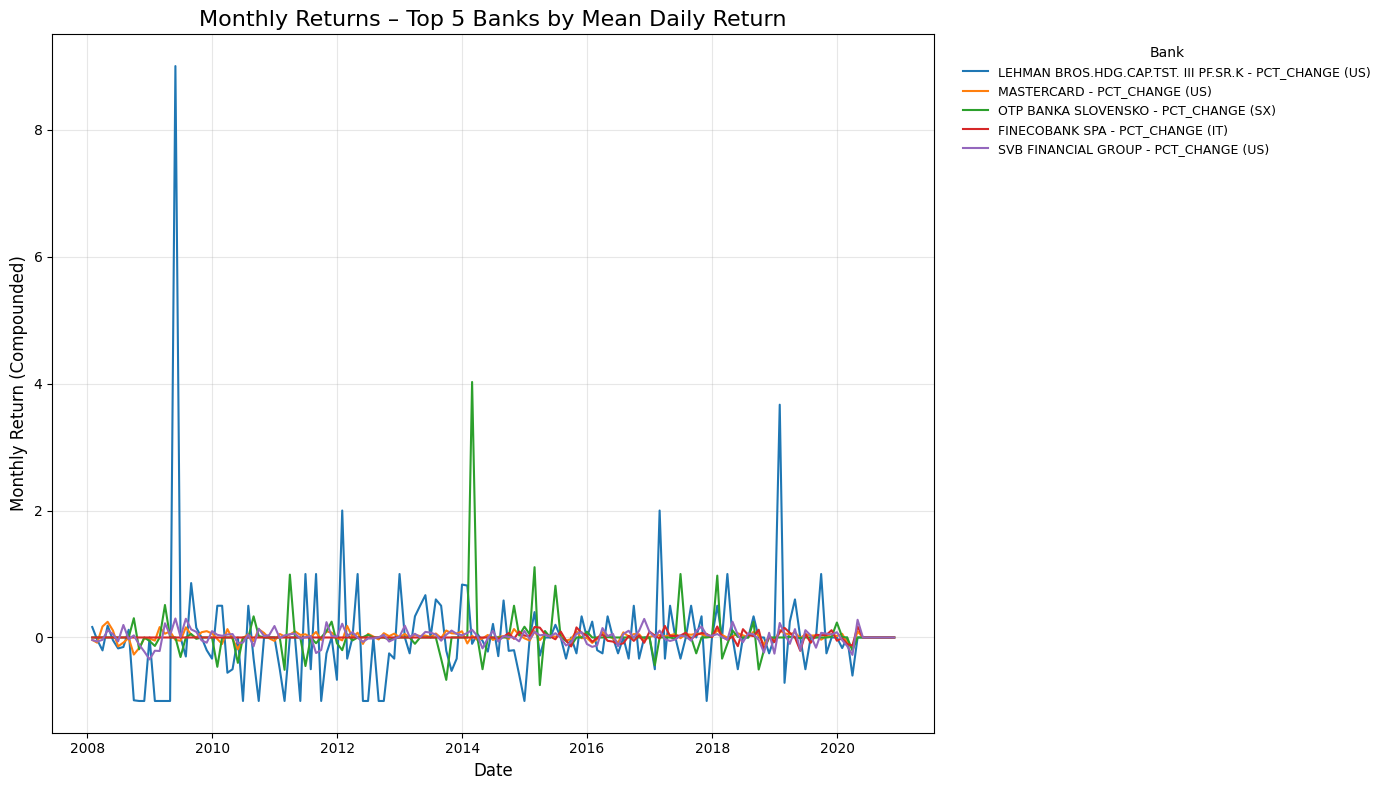

In [126]:
rdf = returns_df.copy()

if "date" in rdf.columns:
    rdf["date"] = pd.to_datetime(rdf["date"], errors="coerce")
    rdf = rdf.set_index("date")
else:
    rdf.index = pd.to_datetime(rdf.index, errors="coerce")

rdf = rdf[~rdf.index.isna()].sort_index()
rdf = rdf.select_dtypes(include="number")

# Compute mean returns and exclude 'MYBANK - PCT_CHANGE (NW)' if present
mean_returns = rdf.mean()
if "MYBANK - PCT_CHANGE (NW)" in mean_returns.index:
    mean_returns = mean_returns.drop("MYBANK - PCT_CHANGE (NW)")

# Find top 5 banks by mean daily return
top5_banks = mean_returns.sort_values(ascending=False).head(5).index
print("Top 5 Banks by Mean Return:", list(top5_banks))

# Monthly compounded returns
top5_returns = rdf[top5_banks]
monthly_returns = (1 + top5_returns).resample("M").prod() - 1

# Larger figure size
plt.figure(figsize=(14, 8))  # wider and taller plot

# Plot lines
for bank in top5_banks:
    plt.plot(monthly_returns.index, monthly_returns[bank], label=bank)

# Titles and labels
plt.title("Monthly Returns – Top 5 Banks by Mean Daily Return", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Monthly Return (Compounded)", fontsize=12)

# Smaller legend
plt.legend(
    title="Bank",
    title_fontsize=10,
    fontsize=9,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

# Grid and layout
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

- **Lehman Brothers Holdings** exhibits **extreme volatility**, with multiple sharp spikes, **some exceeding 800%** (like the one in 2009), indicating severe market disruptions during the financial crisis period.

- **OTP Banka Slovensko** shows **occasional large positive jumps**, likely reflecting illiquidity or corrections in smaller regional markets.

- **Finecobank, SVB Financial Group and Mastercard** maintain **returns close to zero**, demonstrating **stable** and consistent performance over time.

Across the 2008–2020 period, there is **no persistent upward trend**, returns **fluctuate around zero**, reflecting a volatile post-crisis environment with intermittent shocks but limited long-term momentum.

### Avg Returns vs Volatility

In [127]:
return_cols = [col for col in returns_df.columns if 'PCT_CHANGE' in col.upper()]
temp_returns_df = returns_df[return_cols].copy()

# Compute summary statistics
summary_stats = pd.DataFrame({
    'Mean': temp_returns_df.mean(),
    'Std': temp_returns_df.std(),
    'Skewness': temp_returns_df.skew(),
    'Kurtosis': temp_returns_df.kurt()
})

# Sort by mean return
summary_stats = summary_stats.sort_values(by=['Mean', 'Std'], ascending=[False, False])

summary_stats.round(3).head(10)

,Mean,Std,Skewness,Kurtosis
MYBANK - PCT_CHANGE (NW),0.397,12.555,31.527,993.959
LEHMAN BROS.HDG.CAP.TST. III PF.SR.K - PCT_CHANGE (US),0.033,0.354,3.915,38.220
MASTERCARD - PCT_CHANGE (US),0.001,0.021,0.493,10.284
OTP BANKA SLOVENSKO - PCT_CHANGE (SX),0.001,0.061,8.861,221.467
FINECOBANK SPA - PCT_CHANGE (IT),0.001,0.020,-0.137,4.182
SVB FINANCIAL GROUP - PCT_CHANGE (US),0.001,0.027,0.015,8.485
AVANZA BANK HOLDING - PCT_CHANGE (SD),0.001,0.020,0.528,7.170
WESTERN ALL.BANCORP. - PCT_CHANGE (US),0.001,0.034,1.833,50.766
DISCOVER FINANCIAL SVS. - PCT_CHANGE (US),0.001,0.028,0.228,18.157
FIRST REPUBLIC BANK - PCT_CHANGE (US),0.001,0.017,-0.183,11.948


- **MyBank** stands out with an exceptionally **high mean return** but also the **largest volatility and extreme kurtosis**, indicating **rare but massive outliers**.

- **Lehman Brothers Holdings** ranks second by mean return but again shows **very high volatility** and **large skewness**, reflecting heavy asymmetry and crisis-period fluctuations.
  
- **Mastercard and FinecoBank** show **stable and consistent performance with low volatility** and near-zero skewness, suggesting balanced daily movements and limited extreme events.

Overall, there’s **a clear risk–return tradeoff**: banks with **higher returns also tend to show higher volatility**.

## Correlation Matrix for **Top 10 Banks**:
(with the **highest mean return** over the researched period)

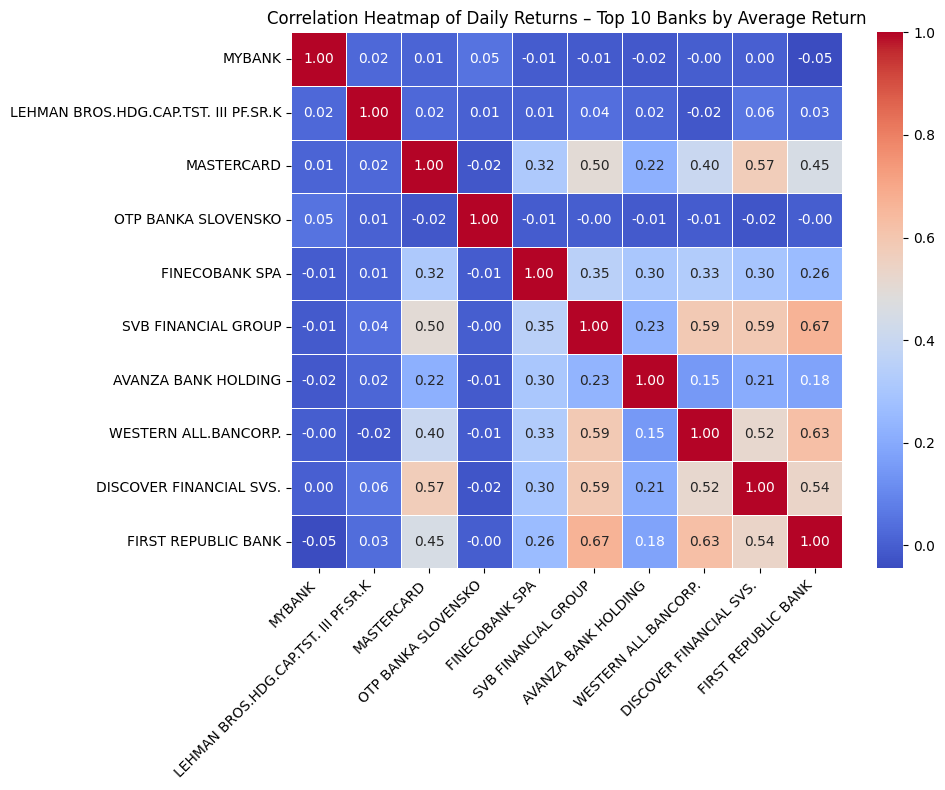

In [128]:
top10_banks = returns_df[return_cols].mean().sort_values(ascending=False).head(10).index
top10_returns = returns_df[top10_banks]

simplified_labels = [col.split('-')[0].strip() for col in top10_banks]
top10_returns.columns = simplified_labels

# --- Compute correlation matrix ---
corr_matrix = top10_returns.corr()

# --- Plot correlation heatmap ---
plt.figure(figsize=(10,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5,
    fmt=".2f"
)
plt.title("Correlation Heatmap of Daily Returns – Top 10 Banks by Average Return")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

- **MYBANK** and **Lehman Brothers Holdings** show **no meaningful correlation** with other banks, suggesting idiosyncratic or unrelated to broader market movements behavior.

- US-based banks such as **Mastercard, SVB Financial Group, Western Alliance Bancorp, Discover Financial Services, and First Republic Bank** show moderate **positive correlations**, indicating shared **exposure to U.S. financial market trends**.

Overall, the heatmap indicates that **cross-bank dependencies are limited**, with most relationships **below 0.5**, implying that these top performers **behave largely independently** and are driven by **bank-specific or regional factors** rather than a single global trend.

## Task #4: 
Estimate parameters of the CAPM (+)

– Use returns data and risk-free rates to estimate the CAPM parameters over a rolling window (or better, use the Fama-French 5 factors model)

– Be careful : the risk free-rate differs for different markets (e.g., US vs. EU)

**Fama-French 3 Factor Model** - no rolling window (with rolling window below):

In [129]:
bank_cols = [col for col in returns_df.columns if re.search(r'\((.*?)\)', col)]
bank_cols = [col for col in bank_cols if col.split('(')[-1].strip(')') in sheet_region_map]

# Filter to US & EU banks only
filtered_banks = [c for c in bank_cols if sheet_region_map[c.split('(')[-1].strip(')')] in ['US','EU']] + ['date']
returns_us_eu = returns_df[filtered_banks].copy()

print(f"Selected {len(filtered_banks)} banks for US/EU regions")
returns_us_eu.head()

Selected 167 banks for US/EU regions


,AAREAL BANK - PCT_CHANGE (BD),COMDIRECT BANK - PCT_CHANGE (BD),COMMERZBANK - PCT_CHANGE (BD),DT.PFANDBRIEFBANK - PCT_CHANGE (BD),PROCREDIT HOLDING - PCT_CHANGE (BD),UMWELTBANK - PCT_CHANGE (BD),ALLIANZ - PCT_CHANGE (BD),DEUTSCHE BANK - PCT_CHANGE (BD),BANQUE NATIONALE DE BELGIQUE - PCT_CHANGE (BG),KBC ANCORA - PCT_CHANGE (BG),KBC GROUP - PCT_CHANGE (BG),BANK OF CYPRUS HOLDING - PCT_CHANGE (CP),HELLENIC BANK - PCT_CHANGE (CP),LHV GROUP - PCT_CHANGE (EO),BBV.ARGENTARIA - PCT_CHANGE (ES),BANCO DE SABADELL - PCT_CHANGE (ES),BANCO SANTANDER - PCT_CHANGE (ES),BANKIA - PCT_CHANGE (ES),BANKINTER 'R' - PCT_CHANGE (ES),CAIXABANK - PCT_CHANGE (ES),LIBERBANK - PCT_CHANGE (ES),UNICAJA BANCO - PCT_CHANGE (ES),AKTIA BANK A - PCT_CHANGE (FN),NORDEA BANK - PCT_CHANGE (FN),BNP PARIBAS - PCT_CHANGE (FR),CRCAM NORD CCI - PCT_CHANGE (FR),CREDIT AGRICOLE - PCT_CHANGE (FR),CREDIT AGRICOLE BRIE PICARDIE - PCT_CHANGE (FR),CREDIT AGR.ILE DE FRANCE - PCT_CHANGE (FR),CREDIT FONCIER DE MONACO - PCT_CHANGE (FR),NATIXIS - PCT_CHANGE (FR),SOCIETE GENERALE - PCT_CHANGE (FR),ALPHA BANK - PCT_CHANGE (GR),ATTICA BANK - PCT_CHANGE (GR),BANK OF GREECE - PCT_CHANGE (GR),BANK OF PIRAEUS - PCT_CHANGE (GR),EUROBANK HOLDINGS - PCT_CHANGE (GR),NATIONAL BK.OF GREECE - PCT_CHANGE (GR),AIB GROUP - PCT_CHANGE (IR),BANK OF IRELAND GROUP - PCT_CHANGE (IR),PERMANENT TSB GHG. - PCT_CHANGE (IR),BANCA GENERALI - PCT_CHANGE (IT),BANCA MONTE DEI PASCHI - PCT_CHANGE (IT),BCA.PICCOLO CDT.VALTELL - PCT_CHANGE (IT),BANCA PPO.DI SONDRIO - PCT_CHANGE (IT),BANCO BPM - PCT_CHANGE (IT),BNC.DI DESIO E DELB. - PCT_CHANGE (IT),BPER BANCA - PCT_CHANGE (IT),CREDITO EMILIANO - PCT_CHANGE (IT),FINECOBANK SPA - PCT_CHANGE (IT),ILLIMITY BANK - PCT_CHANGE (IT),INTESA SANPAOLO - PCT_CHANGE (IT),UNICREDIT - PCT_CHANGE (IT),UNIONE DI BANCHE ITALIAN - PCT_CHANGE (IT),MEDIOBANCA BC.FIN - PCT_CHANGE (IT),SIAULIU BANKAS - PCT_CHANGE (LN),BANK OF VALLETTA - PCT_CHANGE (MA),FIMBANK - PCT_CHANGE (MA),HSBC BANK MALTA - PCT_CHANGE (MA),LOMBARD BANK - PCT_CHANGE (MA),ABN AMRO BANK - PCT_CHANGE (NL),ING GROEP - PCT_CHANGE (NL),NIBC HOLDING - PCT_CHANGE (NL),VAN LANSCHOT KEMPEN - PCT_CHANGE (NL),ASR NEDERLAND - PCT_CHANGE (NL),AEGON - PCT_CHANGE (NL),BANK FUR TIROL UND VBG. - PCT_CHANGE (OE),BAWAG GROUP - PCT_CHANGE (OE),BKS BANK - PCT_CHANGE (OE),ERSTE GROUP BANK - PCT_CHANGE (OE),OBERBANK - PCT_CHANGE (OE),OBERBANK PREF. - PCT_CHANGE (OE),RAIFFEISEN BANK INTL. - PCT_CHANGE (OE),VOLKSBANK VBG.PARTN. - PCT_CHANGE (OE),BANCO COMR.PORTUGUES 'R' - PCT_CHANGE (PT),NOVA LJUBLJANSKA BANK DD NPV - PCT_CHANGE (SJ),OTP BANKA SLOVENSKO - PCT_CHANGE (SX),OTP BANKA SLOVENSKO2 - PCT_CHANGE (SX),OTP BANKA SLOVENSKO3 - PCT_CHANGE (SX),TATRA BANKA - PCT_CHANGE (SX),TATRA BANKA 2 - PCT_CHANGE (SX),VSEOBECNA UVEROVA BANKA - PCT_CHANGE (SX),BANK OF AMERICA - PCT_CHANGE (US),TRUIST FINANCIAL - PCT_CHANGE (US),BOK FINL. - PCT_CHANGE (US),CIT GROUP - PCT_CHANGE (US),CITIZENS FINANCIAL GROUP - PCT_CHANGE (US),COMERICA - PCT_CHANGE (US),COMMERCE BCSH. - PCT_CHANGE (US),CREDICORP - PCT_CHANGE (US),CULLEN FO.BANKERS - PCT_CHANGE (US),DISCOVER FINANCIAL SVS. - PCT_CHANGE (US),EAST WEST BANCORP - PCT_CHANGE (US),FIFTH THIRD BANCORP - PCT_CHANGE (US),FIRST CTZN.BCSH.A - PCT_CHANGE (US),FIRST FINL.BKSH. - PCT_CHANGE (US),FIRST HORIZON NATIONAL - PCT_CHANGE (US),FIRST REPUBLIC BANK - PCT_CHANGE (US),FNB - PCT_CHANGE (US),HUNTINGTON BCSH. - PCT_CHANGE (US),IBERIABANK - PCT_CHANGE (US),KEYCORP - PCT_CHANGE (US),M&T BANK - PCT_CHANGE (US),NEW YORK COMMUNITY BANCORP - PCT_CHANGE (US),PACWEST BANCORP - PCT_CHANGE (US),PEOPLES UNITED FINANCIAL - PCT_CHANGE (US),PINNACLE FINANCIAL PTNS. - PCT_CHANGE (US),PNC FINL.SVS.GP. - PCT_CHANGE (US),POPULAR - PCT_CHANGE (US),PROSPERITY BCSH. - PCT_CHANGE (US),REGIONS FINL.NEW - PCT_CHANGE (US),SIGNATURE BANK - PCT_CHANGE (US),STERLING BANCORP - PCT_CHANGE (US),SVB FINANCIAL GROUP - PCT_CHANGE (US),SYNOVUS FINANCIAL - PCT_CHANGE (US),TCF FINANCIAL - PCT_CHANGE (US),TFS FINANCIAL - PCT_CHANGE (US),TRISTATE CAPITAL

We need to differentiate the factors incorporated into the regression, depending on the **region of the bank - EU or US**:

In [130]:
cols_to_add_US = [
    'Mkt - RF_US', 'SMB_US', 'HML_US', 'RF_US'
]

ff_factors_US = df[cols_to_add_US]
ff_factors_US.columns = ['Mkt_RF', 'SMB', 'HML', 'RF']

cols_to_add_EU = [
    'Mkt - RF_EU', 'SMB_EU', 'HML_EU', 'RF_EU'
]
ff_factors_EU = df[cols_to_add_EU]
ff_factors_EU.columns = ['Mkt_RF', 'SMB', 'HML', 'RF']

In [131]:
ff_factors_US.head()

,Mkt_RF,SMB,HML,RF
date,,,,
2008-01-01,0.04,0.05,0.01,0.01
2008-01-02,-1.25,0.09,-0.22,0.01
2008-01-03,-0.03,-0.66,-0.42,0.01
2008-01-04,-2.59,-0.45,0.29,0.01
2008-01-07,0.02,-0.22,0.24,0.01


In [132]:
returns_us_eu.set_index('date', inplace = True)

In [133]:
returns_us_eu.head()

,AAREAL BANK - PCT_CHANGE (BD),COMDIRECT BANK - PCT_CHANGE (BD),COMMERZBANK - PCT_CHANGE (BD),DT.PFANDBRIEFBANK - PCT_CHANGE (BD),PROCREDIT HOLDING - PCT_CHANGE (BD),UMWELTBANK - PCT_CHANGE (BD),ALLIANZ - PCT_CHANGE (BD),DEUTSCHE BANK - PCT_CHANGE (BD),BANQUE NATIONALE DE BELGIQUE - PCT_CHANGE (BG),KBC ANCORA - PCT_CHANGE (BG),KBC GROUP - PCT_CHANGE (BG),BANK OF CYPRUS HOLDING - PCT_CHANGE (CP),HELLENIC BANK - PCT_CHANGE (CP),LHV GROUP - PCT_CHANGE (EO),BBV.ARGENTARIA - PCT_CHANGE (ES),BANCO DE SABADELL - PCT_CHANGE (ES),BANCO SANTANDER - PCT_CHANGE (ES),BANKIA - PCT_CHANGE (ES),BANKINTER 'R' - PCT_CHANGE (ES),CAIXABANK - PCT_CHANGE (ES),LIBERBANK - PCT_CHANGE (ES),UNICAJA BANCO - PCT_CHANGE (ES),AKTIA BANK A - PCT_CHANGE (FN),NORDEA BANK - PCT_CHANGE (FN),BNP PARIBAS - PCT_CHANGE (FR),CRCAM NORD CCI - PCT_CHANGE (FR),CREDIT AGRICOLE - PCT_CHANGE (FR),CREDIT AGRICOLE BRIE PICARDIE - PCT_CHANGE (FR),CREDIT AGR.ILE DE FRANCE - PCT_CHANGE (FR),CREDIT FONCIER DE MONACO - PCT_CHANGE (FR),NATIXIS - PCT_CHANGE (FR),SOCIETE GENERALE - PCT_CHANGE (FR),ALPHA BANK - PCT_CHANGE (GR),ATTICA BANK - PCT_CHANGE (GR),BANK OF GREECE - PCT_CHANGE (GR),BANK OF PIRAEUS - PCT_CHANGE (GR),EUROBANK HOLDINGS - PCT_CHANGE (GR),NATIONAL BK.OF GREECE - PCT_CHANGE (GR),AIB GROUP - PCT_CHANGE (IR),BANK OF IRELAND GROUP - PCT_CHANGE (IR),PERMANENT TSB GHG. - PCT_CHANGE (IR),BANCA GENERALI - PCT_CHANGE (IT),BANCA MONTE DEI PASCHI - PCT_CHANGE (IT),BCA.PICCOLO CDT.VALTELL - PCT_CHANGE (IT),BANCA PPO.DI SONDRIO - PCT_CHANGE (IT),BANCO BPM - PCT_CHANGE (IT),BNC.DI DESIO E DELB. - PCT_CHANGE (IT),BPER BANCA - PCT_CHANGE (IT),CREDITO EMILIANO - PCT_CHANGE (IT),FINECOBANK SPA - PCT_CHANGE (IT),ILLIMITY BANK - PCT_CHANGE (IT),INTESA SANPAOLO - PCT_CHANGE (IT),UNICREDIT - PCT_CHANGE (IT),UNIONE DI BANCHE ITALIAN - PCT_CHANGE (IT),MEDIOBANCA BC.FIN - PCT_CHANGE (IT),SIAULIU BANKAS - PCT_CHANGE (LN),BANK OF VALLETTA - PCT_CHANGE (MA),FIMBANK - PCT_CHANGE (MA),HSBC BANK MALTA - PCT_CHANGE (MA),LOMBARD BANK - PCT_CHANGE (MA),ABN AMRO BANK - PCT_CHANGE (NL),ING GROEP - PCT_CHANGE (NL),NIBC HOLDING - PCT_CHANGE (NL),VAN LANSCHOT KEMPEN - PCT_CHANGE (NL),ASR NEDERLAND - PCT_CHANGE (NL),AEGON - PCT_CHANGE (NL),BANK FUR TIROL UND VBG. - PCT_CHANGE (OE),BAWAG GROUP - PCT_CHANGE (OE),BKS BANK - PCT_CHANGE (OE),ERSTE GROUP BANK - PCT_CHANGE (OE),OBERBANK - PCT_CHANGE (OE),OBERBANK PREF. - PCT_CHANGE (OE),RAIFFEISEN BANK INTL. - PCT_CHANGE (OE),VOLKSBANK VBG.PARTN. - PCT_CHANGE (OE),BANCO COMR.PORTUGUES 'R' - PCT_CHANGE (PT),NOVA LJUBLJANSKA BANK DD NPV - PCT_CHANGE (SJ),OTP BANKA SLOVENSKO - PCT_CHANGE (SX),OTP BANKA SLOVENSKO2 - PCT_CHANGE (SX),OTP BANKA SLOVENSKO3 - PCT_CHANGE (SX),TATRA BANKA - PCT_CHANGE (SX),TATRA BANKA 2 - PCT_CHANGE (SX),VSEOBECNA UVEROVA BANKA - PCT_CHANGE (SX),BANK OF AMERICA - PCT_CHANGE (US),TRUIST FINANCIAL - PCT_CHANGE (US),BOK FINL. - PCT_CHANGE (US),CIT GROUP - PCT_CHANGE (US),CITIZENS FINANCIAL GROUP - PCT_CHANGE (US),COMERICA - PCT_CHANGE (US),COMMERCE BCSH. - PCT_CHANGE (US),CREDICORP - PCT_CHANGE (US),CULLEN FO.BANKERS - PCT_CHANGE (US),DISCOVER FINANCIAL SVS. - PCT_CHANGE (US),EAST WEST BANCORP - PCT_CHANGE (US),FIFTH THIRD BANCORP - PCT_CHANGE (US),FIRST CTZN.BCSH.A - PCT_CHANGE (US),FIRST FINL.BKSH. - PCT_CHANGE (US),FIRST HORIZON NATIONAL - PCT_CHANGE (US),FIRST REPUBLIC BANK - PCT_CHANGE (US),FNB - PCT_CHANGE (US),HUNTINGTON BCSH. - PCT_CHANGE (US),IBERIABANK - PCT_CHANGE (US),KEYCORP - PCT_CHANGE (US),M&T BANK - PCT_CHANGE (US),NEW YORK COMMUNITY BANCORP - PCT_CHANGE (US),PACWEST BANCORP - PCT_CHANGE (US),PEOPLES UNITED FINANCIAL - PCT_CHANGE (US),PINNACLE FINANCIAL PTNS. - PCT_CHANGE (US),PNC FINL.SVS.GP. - PCT_CHANGE (US),POPULAR - PCT_CHANGE (US),PROSPERITY BCSH. - PCT_CHANGE (US),REGIONS FINL.NEW - PCT_CHANGE (US),SIGNATURE BANK - PCT_CHANGE (US),STERLING BANCORP - PCT_CHANGE (US),SVB FINANCIAL GROUP - PCT_CHANGE (US),SYNOVUS FINANCIAL - PCT_CHANGE (US),TCF FINANCIAL - PCT_CHANGE (US),TFS FINANCIAL - PCT_CHANGE (US),TRISTATE CAPITAL

In [134]:
def run_ff_regression(bank_returns: pd.Series, factors: pd.DataFrame, min_obs: int = 60):
    """
    (R_i - RF) = alpha + b_m*Mkt_RF + b_s*SMB + b_h*HML + eps
    `min_obs` is ignored; regression runs whenever there is at least 1 row after alignment.
    """
    factor_candidates = ["Mkt_RF", "SMB", "HML"]
    Xcols = [c for c in factor_candidates if c in factors.columns]
    need = Xcols + (["RF"] if "RF" in factors.columns else [])

    # align and drop NaNs
    data = pd.concat([bank_returns.rename("Ri"), factors[need]], axis=1, join="inner").dropna()
    if data.empty:
        return None, {"n_obs": 0, "used_factors": Xcols}

    # dependent: excess return if RF is available
    y = data["Ri"] - data["RF"] if "RF" in data.columns else data["Ri"]

    # regress on available factors (const only if none)
    X = sm.add_constant(data[Xcols]) if Xcols else sm.add_constant(pd.DataFrame(index=data.index))

    model = sm.OLS(y, X).fit()
    return model, {"n_obs": len(data), "used_factors": Xcols}

In [135]:
models = {}
rows = []

for bank in filtered_banks:
    code   = bank.split('(')[-1].strip(')')
    region = sheet_region_map.get(code)
    if region not in ("US", "EU"):
        continue

    factors = ff_factors_US if region == "US" else ff_factors_EU

    model, info = run_ff_regression(returns_us_eu[bank], factors[1:], min_obs=60)
    if model is None:
        # Not enough overlapping observations
        print(f"Skipping {bank}: n={info['n_obs']}, used={info['used_factors']}")
        continue

    models[bank] = model
    coef = model.params.to_dict()
    pvals = model.pvalues.to_dict()

    def sig_marker(p):
        if p < 0.01: return "***"  # highly significant
        elif p < 0.05: return "**"
        elif p < 0.1: return "*"
        else: return ""

    rows.append({
        "Bank": bank,
        "Region": region,
        "n_obs": info["n_obs"],
        "Alpha":  coef.get("const", np.nan),
        "Alpha_sig": sig_marker(pvals.get("const", np.nan)),
        "Beta_Mkt": coef.get("Mkt_RF", np.nan),
        "Beta_Mkt_sig": sig_marker(pvals.get("Mkt_RF", np.nan)),
        "Beta_SMB": coef.get("SMB", np.nan),
        "Beta_SMB_sig": sig_marker(pvals.get("SMB", np.nan)),
        "Beta_HML": coef.get("HML", np.nan),
        "Beta_HML_sig": sig_marker(pvals.get("HML", np.nan))
    })

In [136]:
ff5_results = pd.DataFrame(rows)
ff5_results.head(10)

,Bank,Region,n_obs,Alpha,Alpha_sig,Beta_Mkt,Beta_Mkt_sig,Beta_SMB,Beta_SMB_sig,Beta_HML,Beta_HML_sig
0,AAREAL BANK - PCT_CHANGE (BD),EU,3215,-0.002021,***,0.013077,***,0.001204,,0.010991,***
1,COMDIRECT BANK - PCT_CHANGE (BD),EU,3215,-0.002131,***,0.005669,***,0.001216,*,-0.000258,
2,COMMERZBANK - PCT_CHANGE (BD),EU,3215,-0.002893,***,0.010545,***,-0.001584,,0.018060,***
3,DT.PFANDBRIEFBANK - PCT_CHANGE (BD),EU,1249,-0.004478,***,0.010307,***,0.004567,***,0.009994,***
4,PROCREDIT HOLDING - PCT_CHANGE (BD),EU,873,-0.007201,***,0.004699,***,0.005321,**,0.003538,*
5,UMWELTBANK - PCT_CHANGE (BD),EU,3215,-0.001781,***,0.004173,***,0.006268,***,-0.001149,
6,ALLIANZ - PCT_CHANGE (BD),EU,3215,-0.002149,***,0.009058,***,-0.005905,***,0.003637,***
7,DEUTSCHE BANK - PCT_CHANGE (BD),EU,3215,-0.002584,***,0.009087,***,-0.008916,***,0.014230,***
8,BANQUE NATIONALE DE BELGIQUE - PCT_CHANGE (BG),EU,3215,-0.002440,***,0.003557,***,0.003066,***,0.000316,
9,KBC ANCORA - PCT_CHANGE (BG),EU,3215,-0.001829,***,0.013650,***,0.001829,,0.019102,***


In [137]:
sorted_df = ff5_results.sort_values(by="Beta_Mkt", ascending=False)

# Select top and bottom 10
top10 = sorted_df.head(10)
bottom10 = sorted_df.tail(10)

In [138]:
def beta_color(sig):
    if sig == "***":
        return "#08306B"  # dark blue (highly significant)
    elif sig == "**":
        return "#2171B5"  # medium blue
    elif sig == "*":
        return "#6BAED6"  # light blue
    else:
        return "#CCCCCC"  # grey for not significant

In [139]:
# Assign colors
top10_colors = top10["Beta_Mkt_sig"].apply(beta_color)
bottom10_colors = bottom10["Beta_Mkt_sig"].apply(beta_color)

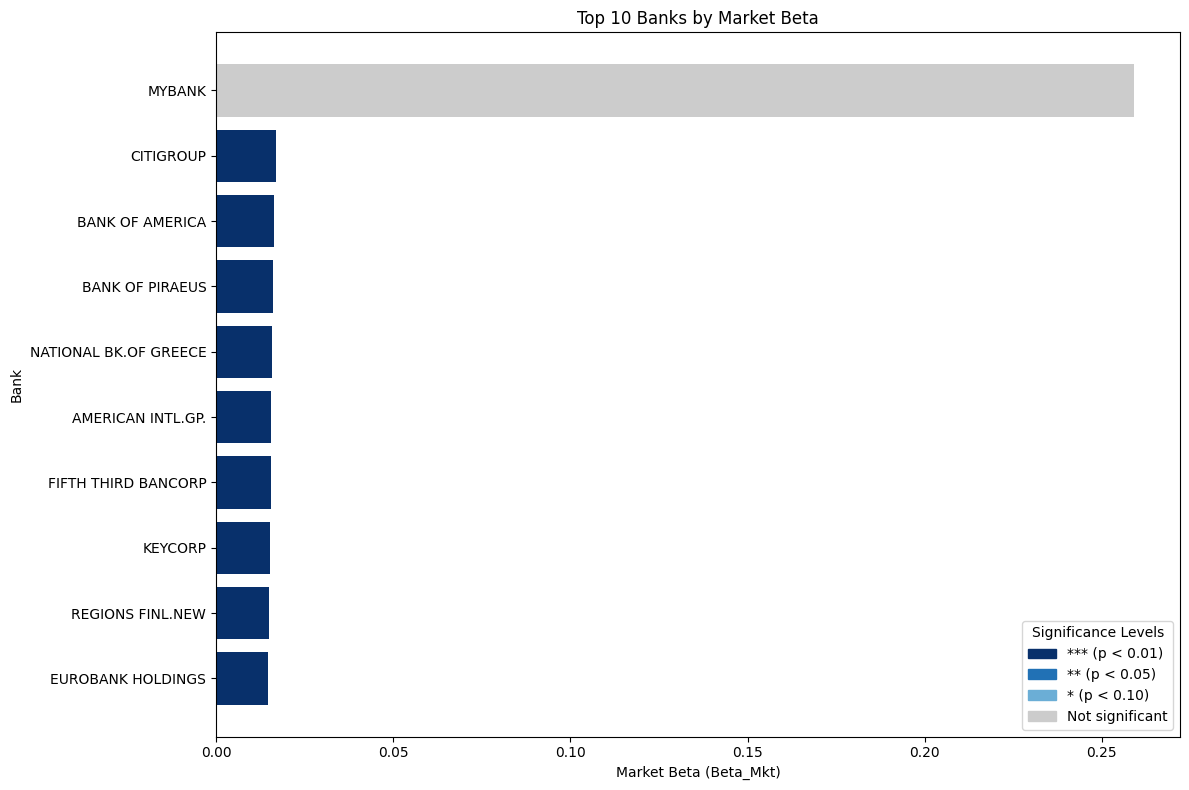

In [140]:
# --- Plot Top 10 ---
plt.figure(figsize=(12, 8))
plt.barh(top10["Bank"].str.split(" -").str[0], top10["Beta_Mkt"], color=top10_colors)

plt.xlabel("Market Beta (Beta_Mkt)")
plt.ylabel("Bank")
plt.title("Top 10 Banks by Market Beta")
plt.gca().invert_yaxis()

# --- Add legend manually ---
import matplotlib.patches as mpatches
legend_patches = [
    mpatches.Patch(color="#08306B", label="*** (p < 0.01)"),
    mpatches.Patch(color="#2171B5", label="** (p < 0.05)"),
    mpatches.Patch(color="#6BAED6", label="* (p < 0.10)"),
    mpatches.Patch(color="#CCCCCC", label="Not significant"),
]
plt.legend(handles=legend_patches, title="Significance Levels", loc="lower right", frameon=True)

plt.tight_layout()
plt.show()

- **Statistical Significance:**
  
The coefficient is **statistically insignificant** for MyBank, suggesting that its performance may be driven more by **idiosyncratic or firm-specific factors** than by broad market trends.

- **Clustered majority:**
  
Most banks have betas around 0.01–0.02, showing **very low sensitivity to market movements**.

- **Regional pattern:**
  
Several European banks appear in the Top 10, highlighting **varied market exposure even within the EU region**.

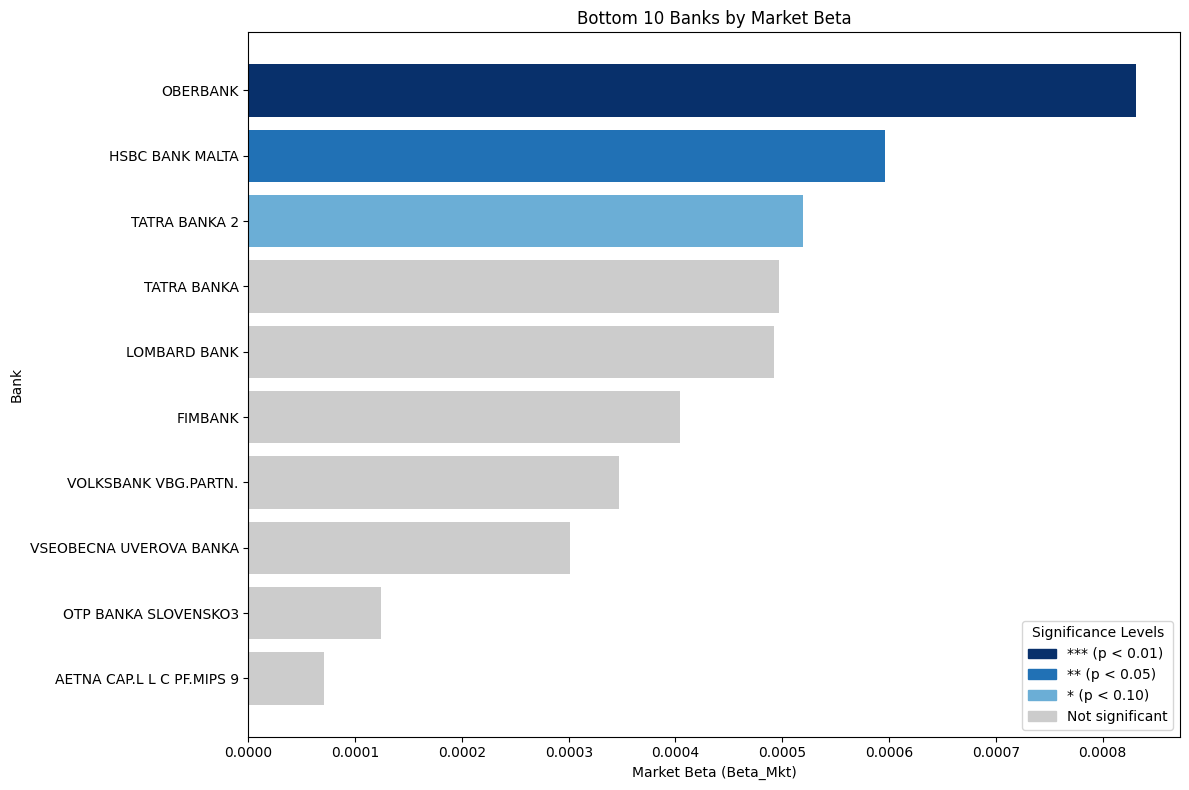

In [141]:
# --- Plot Bottom 10 ---
plt.figure(figsize=(12, 8))
plt.barh(bottom10["Bank"].str.split(" -").str[0], bottom10["Beta_Mkt"], color=bottom10_colors)
plt.xlabel("Market Beta (Beta_Mkt)")
plt.ylabel("Bank")
plt.title("Bottom 10 Banks by Market Beta")
plt.gca().invert_yaxis()

# --- Add legend manually ---
import matplotlib.patches as mpatches
legend_patches = [
    mpatches.Patch(color="#08306B", label="*** (p < 0.01)"),
    mpatches.Patch(color="#2171B5", label="** (p < 0.05)"),
    mpatches.Patch(color="#6BAED6", label="* (p < 0.10)"),
    mpatches.Patch(color="#CCCCCC", label="Not significant"),
]
plt.legend(handles=legend_patches, title="Significance Levels", loc="lower right", frameon=True)

plt.tight_layout()
plt.show()

- **Statistical significance:**
  
Most coefficients are **statistically insignificant**, meaning their link to market movements is not robust. Only a few show weak to moderate significance.

- **Near-zero or negative betas:**

Several banks show betas close to zero or slightly negative, implying **minimal or inverse correlation with market movements**.

- **Low market sensitivity**:

These institutions are largely behaving more like **locally driven banks**.

In [142]:
# --- Split by region ---
eu_df = ff5_results[ff5_results["Region"] == "EU"]
us_df = ff5_results[ff5_results["Region"] == "US"]

# --- Sort and select top/bottom 5 for each ---
eu_top5 = eu_df.sort_values(by="Beta_Mkt", ascending=False).head(5)
eu_bottom5 = eu_df.sort_values(by="Beta_Mkt", ascending=True).head(5)
us_top5 = us_df.sort_values(by="Beta_Mkt", ascending=False).head(5)
us_bottom5 = us_df.sort_values(by="Beta_Mkt", ascending=True).head(5)

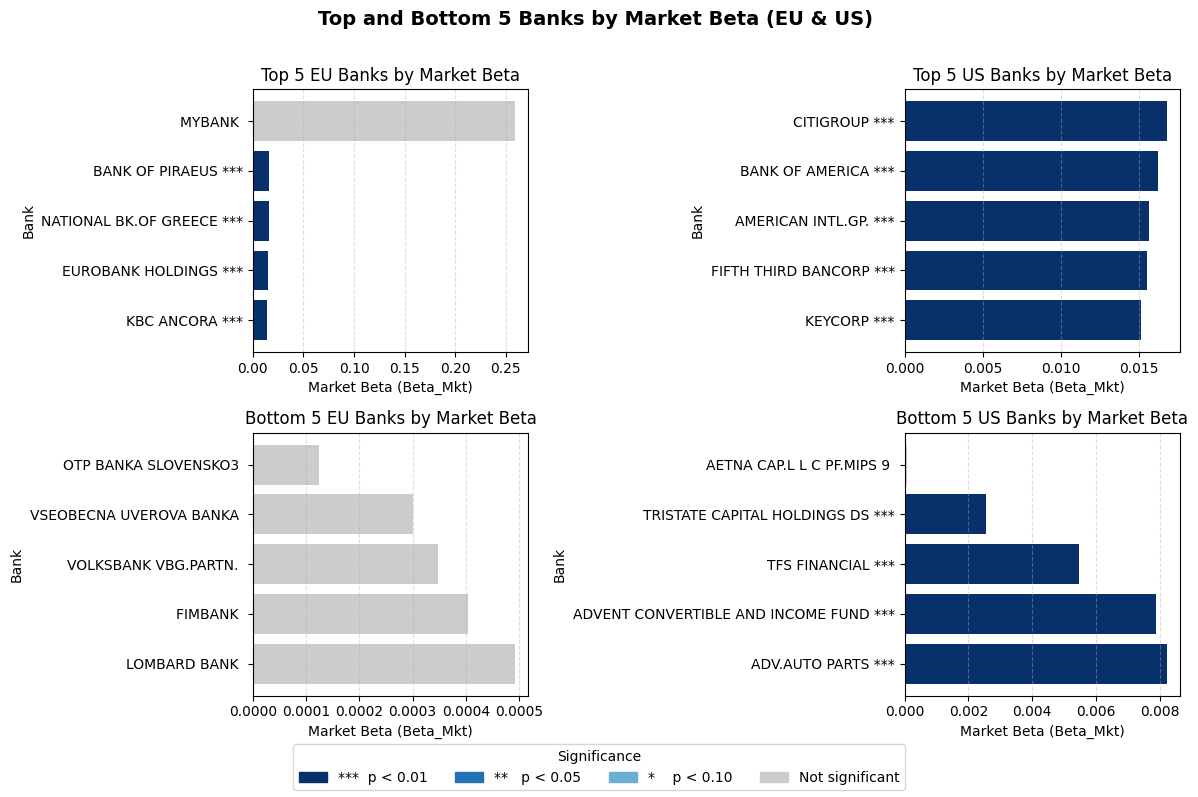

In [143]:
# --- Color + star helpers ---
def beta_color(sig):
    if sig == "***": return "#08306B"   # p<0.01
    if sig == "**":  return "#2171B5"   # p<0.05
    if sig == "*":   return "#6BAED6"   # p<0.10
    return "#CCCCCC"                     # not significant

def add_stars(s):  # pretty-print stars (or blank if NaN)
    return s if s in ("*", "**", "***") else ""

# Build labels (bank name + stars) and colors for each panel
eu_top5_labels   = eu_top5["Bank"].str.split(" -").str[0] + " " + eu_top5["Beta_Mkt_sig"].map(add_stars).fillna("")
eu_bottom5_labels= eu_bottom5["Bank"].str.split(" -").str[0] + " " + eu_bottom5["Beta_Mkt_sig"].map(add_stars).fillna("")
us_top5_labels   = us_top5["Bank"].str.split(" -").str[0] + " " + us_top5["Beta_Mkt_sig"].map(add_stars).fillna("")
us_bottom5_labels= us_bottom5["Bank"].str.split(" -").str[0] + " " + us_bottom5["Beta_Mkt_sig"].map(add_stars).fillna("")

eu_top5_colors    = eu_top5["Beta_Mkt_sig"].map(beta_color).fillna("#CCCCCC")
eu_bottom5_colors = eu_bottom5["Beta_Mkt_sig"].map(beta_color).fillna("#CCCCCC")
us_top5_colors    = us_top5["Beta_Mkt_sig"].map(beta_color).fillna("#CCCCCC")
us_bottom5_colors = us_bottom5["Beta_Mkt_sig"].map(beta_color).fillna("#CCCCCC")

# --- Create 2x2 subplot grid ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Top and Bottom 5 Banks by Market Beta (EU & US)", fontsize=14, fontweight='bold')

# Top 5 EU
axes[0, 0].barh(eu_top5_labels, eu_top5["Beta_Mkt"], color=eu_top5_colors)
axes[0, 0].set_title("Top 5 EU Banks by Market Beta")
axes[0, 0].invert_yaxis()

# Bottom 5 EU
axes[1, 0].barh(eu_bottom5_labels, eu_bottom5["Beta_Mkt"], color=eu_bottom5_colors)
axes[1, 0].set_title("Bottom 5 EU Banks by Market Beta")
axes[1, 0].invert_yaxis()

# Top 5 US
axes[0, 1].barh(us_top5_labels, us_top5["Beta_Mkt"], color=us_top5_colors)
axes[0, 1].set_title("Top 5 US Banks by Market Beta")
axes[0, 1].invert_yaxis()

# Bottom 5 US
axes[1, 1].barh(us_bottom5_labels, us_bottom5["Beta_Mkt"], color=us_bottom5_colors)
axes[1, 1].set_title("Bottom 5 US Banks by Market Beta")
axes[1, 1].invert_yaxis()

# --- Common styling ---
for ax in axes.flat:
    ax.set_xlabel("Market Beta (Beta_Mkt)")
    ax.set_ylabel("Bank")
    ax.grid(axis='x', linestyle='--', alpha=0.4)

# --- Significance legend ---
legend_patches = [
    mpatches.Patch(color="#08306B", label="***  p < 0.01"),
    mpatches.Patch(color="#2171B5", label="**   p < 0.05"),
    mpatches.Patch(color="#6BAED6", label="*    p < 0.10"),
    mpatches.Patch(color="#CCCCCC", label="Not significant"),
]
fig.legend(handles=legend_patches, title="Significance", loc="lower center", ncol=4, frameon=True)

plt.tight_layout(rect=[0, 0.05, 1, 0.97])
plt.show()

**EU banks** have some market betas close to zero, with several being statistically insignificant.
This indicates **weak or negligible exposure to overall market movements**, suggesting their returns are largely driven by **idiosyncratic or regional factors**.

**US** banks show narrower, more **uniform betas**, nearly **all statistically significant**, indicating more exposure to systematic market risk (although still close to 0).

**EU banks** display greater **idiosyncratic** variation, while **US banks** move more in line with **market trends**, reflecting systematic risk dominance in the US and diverse sensitivities in Europe.

**Fama-French 3 Factor Model** - **with rolling window:**

In [144]:
def run_ff_regression_rolling(bank_returns: pd.Series, factors: pd.DataFrame, window: int = 60):
    """
    Runs a rolling-window Fama-French regression:
    (R_i - RF) = alpha + b_m*Mkt_RF + b_s*SMB + b_h*HML + eps
    """
    factor_candidates = ["Mkt_RF", "SMB", "HML"]
    Xcols = [c for c in factor_candidates if c in factors.columns]
    need = Xcols + (["RF"] if "RF" in factors.columns else [])

    # align and drop NaNs
    data = pd.concat([bank_returns.rename("Ri"), factors[need]], axis=1, join="inner").dropna()
    if data.empty:
        return None

    # dependent variable
    y = data["Ri"] - data["RF"] if "RF" in data.columns else data["Ri"]

    # store betas through time
    betas = pd.DataFrame(index=data.index, columns=["Alpha"] + Xcols)

    # rolling window regression
    for end in range(window, len(data)):
        sub = data.iloc[end-window:end]
        y_sub = sub["Ri"] - sub["RF"] if "RF" in sub.columns else sub["Ri"]
        X_sub = sm.add_constant(sub[Xcols])
        model = sm.OLS(y_sub, X_sub).fit()
        betas.loc[data.index[end], ["Alpha"] + Xcols] = model.params.values

    return betas.dropna()

For **Top 10 banks** in terms of average returns over the researched period:

In [145]:
# --- Run rolling regression for top 10 banks ---
rolling_results = {}

for bank in top10_banks:
    # Determine region for correct factor set
    code = bank.split('(')[-1].strip(')')
    region = sheet_region_map.get(code)
    factors = ff_factors_US if region == "US" else ff_factors_EU

    print(f"Running rolling regression for {bank} ({region})...")
    result = run_ff_regression_rolling(returns_us_eu[bank], factors, window=60)
    if result is not None:
        rolling_results[bank] = result
    else:
        print(f"⚠️ Skipping {bank}: not enough data for rolling window")

Running rolling regression for MYBANK - PCT_CHANGE (NW) (EU)...
Running rolling regression for LEHMAN BROS.HDG.CAP.TST. III PF.SR.K - PCT_CHANGE (US) (US)...
Running rolling regression for MASTERCARD - PCT_CHANGE (US) (US)...
Running rolling regression for OTP BANKA SLOVENSKO - PCT_CHANGE (SX) (EU)...
Running rolling regression for FINECOBANK SPA - PCT_CHANGE (IT) (EU)...
Running rolling regression for SVB FINANCIAL GROUP - PCT_CHANGE (US) (US)...
Running rolling regression for AVANZA BANK HOLDING - PCT_CHANGE (SD) (EU)...
Running rolling regression for WESTERN ALL.BANCORP. - PCT_CHANGE (US) (US)...
Running rolling regression for DISCOVER FINANCIAL SVS. - PCT_CHANGE (US) (US)...
Running rolling regression for FIRST REPUBLIC BANK - PCT_CHANGE (US) (US)...


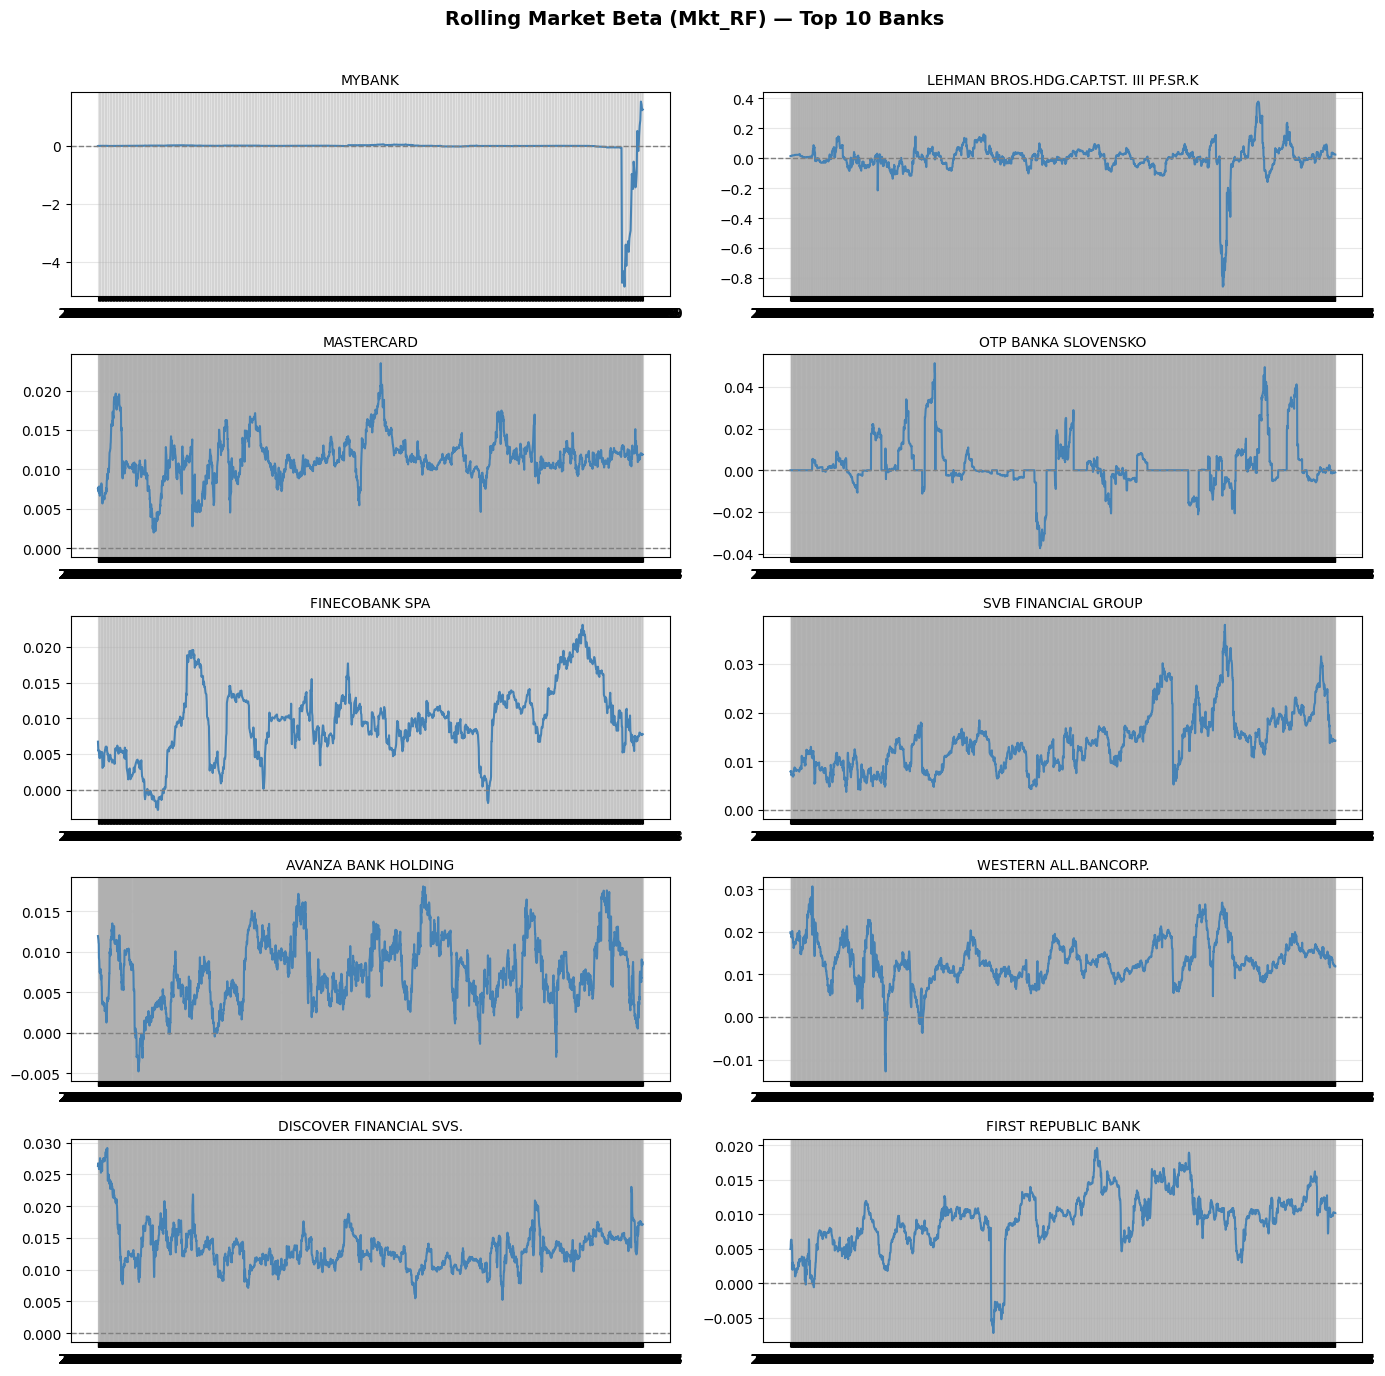

In [146]:
banks_to_plot = [b for b in top10_banks if b in rolling_results]

# Create 5x2 subplot grid
fig, axes = plt.subplots(5, 2, figsize=(14, 14))
axes = axes.flatten()

for i, bank in enumerate(banks_to_plot[:10]):
    ax = axes[i]
    beta_series = rolling_results[bank]["Mkt_RF"].dropna()
    ax.plot(beta_series, label="Rolling Beta", color="steelblue")
    ax.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax.set_title(bank.split(" -")[0], fontsize=10)
    ax.grid(alpha=0.3)

# Hide any unused subplots
for j in range(len(banks_to_plot), len(axes)):
    axes[j].axis("off")

fig.suptitle("Rolling Market Beta (Mkt_RF) — Top 10 Banks", fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

**US banks** show, in general, **more stable and persistent** exposure to market risk, while **EU banks** display lower or less reliable betas, reflecting **greater idiosyncratic influence and weaker market integration.**

## Task #5:
Compute CARs and merge Sigwatch + Datastream data (++)

– Merge with the Sigwatch data to define the event dates (a event is a positive/negative campaign)

– Compute the CARs around the event date (-10, +10 is the baseline, but you may want to try other time periods)

Preparing the dataset:

In [148]:
# Merge with the Sigwatch data to define the event dates

# 0) Read and prepare Fama-French factors (US/EU).
def load_ff(path, rename_map):
    f = pd.read_excel(path)
    # Normalize date column name
    date_col = 'date' if 'date' in f.columns else ('Date' if 'Date' in f.columns else None)
    if date_col is None:
        for cand in ['DATE','Date','dt','DT']:
            if cand in f.columns:
                date_col = cand
                break
    if date_col is None:
        raise ValueError(f"No date column found in {path}.")
    f = f.rename(columns={date_col: 'date'})
    f['date'] = pd.to_datetime(f['date'], errors='coerce')
    f = f.sort_values('date')
    f = f.rename(columns=rename_map)
    # Keep only needed cols, standard names
    keep = ['date','Mkt_RF','SMB','HML','RF']
    f = f[[c for c in keep if c in f.columns]]
    return f.set_index('date')

# Correct (US = North America, EU = Europe)
FF_US = load_ff(
    'banks_data_bocconi/North_America_3_Factors_Daily.xlsx',
    rename_map={'Mkt-RF':'Mkt_RF', 'Mkt - RF':'Mkt_RF', 'RF':'RF', 'SMB':'SMB', 'HML':'HML'}
)
FF_EU = load_ff(
    'banks_data_bocconi/Europe_3_Factors_Daily.xlsx',
    rename_map={'Mkt-RF':'Mkt_RF', 'Mkt - RF':'Mkt_RF', 'RF':'RF', 'SMB':'SMB', 'HML':'HML'}
)

In [149]:
# 1) Build company -> region map from returns_df columns
#    Use the sheet code in parentheses to map to US/EU/UK, then fold UK into EU for factors.
company_to_region = {}
pattern = re.compile(r'^(.*?)\s*-\s*PCT_CHANGE\s*\((.*?)\)\s*$')
for col in returns_df.columns:
    if 'PCT_CHANGE' not in col:
        continue
    m = pattern.match(col)
    if not m:
        continue
    company = m.group(1).strip()
    code = m.group(2).strip()
    region = sheet_region_map.get(code)  # e.g., 'US','EU','UK',...
    if region == 'UK':
        region = 'EU'  # <- use EU factors for UK banks (adjust if you have UK-specific factors)
    if region in ('US','EU'):
        company_to_region[company] = region

In [150]:
# 2) Make returns long with the correct dates (no cross-contamination from other dfs)
ret_wide = returns_df.copy()
if 'date' not in ret_wide.columns:
    ret_wide = ret_wide.reset_index().rename(columns={'index':'date'})
ret_wide['date'] = pd.to_datetime(ret_wide['date'], errors='coerce')

returns_long = (
    ret_wide
    .melt(id_vars='date', var_name='company_col', value_name='pct_change')
    .dropna(subset=['date'])
    .copy()
)

# Company label without " - PCT_CHANGE (CODE)"
returns_long['company'] = (
    returns_long['company_col']
    .str.replace(r'\s*-\s*PCT_CHANGE\s*\(.*?\)\s*$', '', regex=True)
    .str.strip()
)

In [151]:
# 3) Read Sigwatch events and align by normalized names (ISIN join is better if you have it)
events_raw = pd.read_csv('events_date_ngos_company_wide.csv')
events_raw['date'] = pd.to_datetime(events_raw['date'], errors='coerce')

def normalize_name(s):
    if pd.isna(s): return ""
    s = s.lower()
    s = re.sub(r"&", "and", s)
    s = re.sub(r"[^a-z0-9]+", " ", s)
    return s.strip()

returns_long['company_norm'] = returns_long['company'].map(normalize_name)
events_raw['name_norm'] = events_raw['isin_corporate_name_cleaned'].map(normalize_name)

# Keep only name overlaps (you can switch to ISIN-based merge if both sides have ISIN)
matched_names = set(returns_long['company_norm']).intersection(set(events_raw['name_norm']))
events = (
    events_raw[events_raw['name_norm'].isin(matched_names)]
    [['date','name_norm']].dropna().drop_duplicates().assign(event=1)
)

# 4) Flag event days in returns_long
returns_long = (
    returns_long.merge(events, how='left',
                       left_on=['date','company_norm'],
                       right_on=['date','name_norm'])
    .drop(columns=['name_norm'])
)
returns_long['event'] = returns_long['event'].fillna(0).astype(int)

# Optionally keep only companies we can map to a region (US/EU)
returns_long = returns_long[returns_long['company'].isin(company_to_region.keys())].copy()

print("Matched events:", int(returns_long['event'].sum()))
print("Rows in returns_long:", len(returns_long))

Matched events: 1328
Rows in returns_long: 598436


**Sanity Checks** for the matching process:

In [152]:
# ===== Minimal sanity checks for the match =====

# 0) Basic volumes
print("Total rows in returns_long:", len(returns_long))
print("Total raw events rows:", len(events_raw))
print("Unique firms in returns_long:", returns_long['company'].nunique())
print("Unique normalized names in events_raw:", events_raw['name_norm'].nunique())
print("Event flags in returns_long (should be <= total raw events):", int(returns_long['event'].sum()))

Total rows in returns_long: 598436
Total raw events rows: 6574
Unique firms in returns_long: 178
Unique normalized names in events_raw: 120
Event flags in returns_long (should be <= total raw events): 1328


In [153]:
# 1) What fraction of event names are totally unmatched? (recall check)
ev_only = set(events_raw['name_norm']) - set(returns_long['company_norm'])
print("Unmatched event names:", len(ev_only), "out of", events_raw['name_norm'].nunique(),
      f"({100*len(ev_only)/events_raw['name_norm'].nunique():.1f}% unmatched)")
print("Sample:", list(sorted(ev_only))[:10])


Unmatched event names: 96 out of 120 (80.0% unmatched)
Sample: ['', '3i', 'admiral', 'aetna', 'aimia', 'allied irish banks', 'allstate', 'american international', 'american national insurance', 'aon']


In [154]:
# 2) Do matched events survive after factor-join? (date alignment check)
def _post_join_event_survival(check_region='US'):
    F = FF_US if check_region == 'US' else FF_EU
    comps = [c for c, r in company_to_region.items() if r == check_region]
    sub = returns_long[returns_long['company'].isin(comps)]
    before = int(sub['event'].sum())
    after = int(sub.set_index('date').join(F, how='left')['event'].fillna(0).sum())
    print(f"[{check_region}] events before factor-join: {before} | after factor-join: {after} "
          f"({after/before*100:.1f}% kept)" if before else f"[{check_region}] no events")

_post_join_event_survival('US')
_post_join_event_survival('EU')


[US] events before factor-join: 219 | after factor-join: 219 (100.0% kept)
[EU] events before factor-join: 1109 | after factor-join: 1109 (100.0% kept)


In [155]:
# 1) Quick sample of matched rows (event==1)
matched_sample = returns_long.loc[returns_long['event'] == 1, 
                                  ['date','company','company_norm','company_col']].sample(15, random_state=42)
display(matched_sample)

,date,company,company_norm,company_col
489285,2014-11-19,BARCLAYS,barclays,BARCLAYS - PCT_CHANGE (UK)
22936,2018-08-07,ALLIANZ,allianz,ALLIANZ - PCT_CHANGE (BD)
290526,2013-05-07,BANK OF AMERICA,bank of america,BANK OF AMERICA - PCT_CHANGE (US)
24945,2013-05-30,DEUTSCHE BANK,deutsche bank,DEUTSCHE BANK - PCT_CHANGE (BD)
21681,2013-10-15,ALLIANZ,allianz,ALLIANZ - PCT_CHANGE (BD)
106799,2017-11-17,SOCIETE GENERALE,societe generale,SOCIETE GENERALE - PCT_CHANGE (FR)
213016,2012-08-22,ING GROEP,ing groep,ING GROEP - PCT_CHANGE (NL)
83233,2017-10-04,BNP PARIBAS,bnp paribas,BNP PARIBAS - PCT_CHANGE (FR)
81709,2011-12-01,BNP PARIBAS,bnp paribas,BNP PARIBAS - PCT_CHANGE (FR)
105217,2011-10-26,SOCIETE GENERALE,societe generale,SOCIETE GENERALE - PCT_CHANGE (FR)


Based on the randomly sampled subsample of matched events to returns dataset, it seems like the matching has been performed successfully, what allows us now to apply this information to perform CAPM estimation on the predefined time window, in a specific time-distance before the event:

**Step 1:** 

Estimate CAPM parameters for stock i at time ts

**Step 2:** 

Estimate abnormal return at time t

**Step 3:** 

Compute cumulative abnormal returns

In [156]:
def event_study_capm(
    returns_long: pd.DataFrame,
    company_to_region: dict,
    FF_US: pd.DataFrame,
    FF_EU: pd.DataFrame,
    est_len: int = 250,   # estimation window length
    gap: int = 50,        # gap between estimation window and event day
    event_win: int = 10,  # +/- window length (baseline: 10)
    min_est_obs: int = 120
) -> pd.DataFrame:
    """
    For each (company, event_date):
      Step 1: Estimate CAPM in [t_s - gap - est_len, t_s - gap)
      Step 2: Compute AR_t in [t_s - event_win, t_s + event_win]
      Step 3: CAR = sum_t AR_t over the event window
    """
    out = []

    df0 = returns_long.dropna(subset=['date','pct_change']).copy()
    df0['date'] = pd.to_datetime(df0['date'], errors='coerce')
    df0 = df0.sort_values(['company','date'])

    for comp, sub in df0.groupby('company', sort=False):
        region = company_to_region.get(comp)
        if region not in ('US','EU'):
            continue

        F = FF_US if region == 'US' else FF_EU

        # Join with factors by date
        sub = (
            sub.set_index('date')
               .join(F, how='left')
               .dropna(subset=['pct_change','Mkt_RF','RF'])
               .sort_index()
        )
        if sub.empty: 
            continue

        sub['excess'] = sub['pct_change'] - sub['RF']

        # All event dates that exist in sub after the join
        ev_idx = sub.index[sub['event'] == 1]
        if len(ev_idx) == 0:
            continue

        for t0 in ev_idx:
            if t0 not in sub.index:
                continue
            pos = sub.index.get_loc(t0)

            # Estimation window: [pos - gap - est_len, pos - gap)
            est_start = pos - gap - est_len
            est_end   = pos - gap
            if isinstance(est_start, slice) or est_start < 0 or est_end <= est_start:
                continue

            est = sub.iloc[est_start:est_end].copy()
            if len(est) < min_est_obs:
                continue

            # ---- Step 1: CAPM parameters ----
            y = est['excess']
            X = sm.add_constant(est[['Mkt_RF']])
            model = sm.OLS(y, X).fit()
            alpha_hat = model.params.get('const', np.nan)
            beta_hat  = model.params.get('Mkt_RF', np.nan)

            # ---- Step 2 & 3: AR and CAR over the event window ----
            win_start = max(0, pos - event_win)
            win_end   = min(len(sub)-1, pos + event_win)
            win = sub.iloc[win_start:win_end+1].copy()

            win['expected'] = alpha_hat + beta_hat * win['Mkt_RF']
            win['AR'] = win['excess'] - win['expected']
            CAR = win['AR'].sum()

            out.append({
                'company': comp,
                'region': region,
                'event_date': t0,
                'alpha_hat': alpha_hat,
                'beta_hat': beta_hat,
                'CAR_-{0}_+{0}'.format(event_win): CAR,
                'n_est': len(est),
                'n_win': len(win)
            })

    return pd.DataFrame(out).sort_values(['company','event_date']).reset_index(drop=True)

In [157]:
# ---- Run baseline: +/-10 days, 250-day estimation, 50-day gap ----
car_df = event_study_capm(
    returns_long=returns_long,
    company_to_region=company_to_region,
    FF_US=FF_US,
    FF_EU=FF_EU,
    est_len=250,
    gap=50,
    event_win=10,
    min_est_obs=120
)

display(car_df.head(10))
print("Computed CARs:", len(car_df))

,company,region,event_date,alpha_hat,beta_hat,CAR_-10_+10,n_est,n_win
0,AEGON,EU,2010-04-09,-0.002179,0.023061,0.032046,250,21
1,AEGON,EU,2010-04-12,-0.001952,0.023075,0.015679,250,21
2,AEGON,EU,2010-07-05,-0.000988,0.016915,-0.125556,250,21
3,AEGON,EU,2011-02-01,-0.000221,0.012194,0.007145,250,21
4,AEGON,EU,2011-04-27,-0.000116,0.011175,-0.025893,250,21
5,AEGON,EU,2011-09-26,-0.001012,0.009996,0.166643,250,21
6,AEGON,EU,2011-10-11,-0.001018,0.010611,0.106335,250,21
7,AEGON,EU,2012-01-27,-0.000642,0.013955,0.005023,250,21
8,AEGON,EU,2012-02-14,-0.000436,0.014210,0.009438,250,21
9,AEGON,EU,2012-04-02,-0.000484,0.014863,-0.131258,250,21


Computed CARs: 1328


In [158]:
# (Optional) Try other windows, e.g., +/-5, +/-20
car_df_5  = event_study_capm(returns_long, company_to_region, FF_US, FF_EU, 250, 50, 5)
# car_df_20 = event_study_capm(returns_long, company_to_region, FF_US, FF_EU, 250, 50, 20)
display(car_df_5.head(10))
print("Computed CARs:", len(car_df_5))

,company,region,event_date,alpha_hat,beta_hat,CAR_-5_+5,n_est,n_win
0,AEGON,EU,2010-04-09,-0.002179,0.023061,0.054259,250,11
1,AEGON,EU,2010-04-12,-0.001952,0.023075,0.041997,250,11
2,AEGON,EU,2010-07-05,-0.000988,0.016915,-0.045218,250,11
3,AEGON,EU,2011-02-01,-0.000221,0.012194,0.028954,250,11
4,AEGON,EU,2011-04-27,-0.000116,0.011175,-0.018046,250,11
5,AEGON,EU,2011-09-26,-0.001012,0.009996,0.057500,250,11
6,AEGON,EU,2011-10-11,-0.001018,0.010611,-0.006278,250,11
7,AEGON,EU,2012-01-27,-0.000642,0.013955,-0.037188,250,11
8,AEGON,EU,2012-02-14,-0.000436,0.014210,0.020246,250,11
9,AEGON,EU,2012-04-02,-0.000484,0.014863,-0.034253,250,11


Computed CARs: 1328


In [159]:
# ========= 1) Compute per-event AR paths and cumulative sums (CAR_tau) =========
def event_study_capm_paths(
    returns_long: pd.DataFrame,
    company_to_region: dict,
    FF_US: pd.DataFrame,
    FF_EU: pd.DataFrame,
    est_len: int = 250,
    gap: int = 50,
    event_win: int = 10,
    min_est_obs: int = 120,
) -> pd.DataFrame:
    """
    Returns a long DF with per-event AR_t and CAR_tau for tau in [-event_win, +event_win].
    Columns: company, region, event_date, date, tau, AR, CAR_tau
    """
    rows = []

    df0 = returns_long.dropna(subset=['date','pct_change']).copy()
    df0['date'] = pd.to_datetime(df0['date'], errors='coerce')
    df0 = df0.sort_values(['company','date'])

    for comp, sub in df0.groupby('company', sort=False):
        region = company_to_region.get(comp)
        if region not in ('US','EU'):
            continue

        F = FF_US if region == 'US' else FF_EU

        sub = (sub.set_index('date')
                  .join(F, how='left')
                  .dropna(subset=['pct_change','Mkt_RF','RF'])
                  .sort_index())

        if sub.empty:
            continue

        sub['excess'] = sub['pct_change'] - sub['RF']
        ev_idx = sub.index[sub['event'] == 1]
        if len(ev_idx) == 0:
            continue

        for t0 in ev_idx:
            pos = sub.index.get_loc(t0)
            est_start = pos - gap - est_len
            est_end   = pos - gap
            if isinstance(est_start, slice) or est_start < 0 or est_end <= est_start:
                continue
            est = sub.iloc[est_start:est_end].copy()
            if len(est) < min_est_obs:
                continue

            # CAPM fit
            y = est['excess']
            X = sm.add_constant(est[['Mkt_RF']])
            model = sm.OLS(y, X).fit()
            alpha_hat = model.params.get('const', np.nan)
            beta_hat  = model.params.get('Mkt_RF', np.nan)

            # Event window data
            win_start = max(0, pos - event_win)
            win_end   = min(len(sub)-1, pos + event_win)
            win = sub.iloc[win_start:win_end+1].copy()

            # Event-time index tau = t - t0
            tau = (win.index - t0).days  # calendar days; still ok since index is trading days
            win = win.assign(
                tau=tau,
                expected=alpha_hat + beta_hat * win['Mkt_RF'],
            )
            win['AR'] = win['excess'] - win['expected']
            win = win.sort_values('tau')
            win['CAR_tau'] = win['AR'].cumsum()

            for _, r in win.reset_index().iterrows():
                rows.append({
                    'company': comp,
                    'region': region,
                    'event_date': t0,
                    'date': r['date'],
                    'tau': int(r['tau']),
                    'AR': float(r['AR']),
                    'CAR_tau': float(r['CAR_tau']),
                })

    return pd.DataFrame(rows)

car_paths = event_study_capm_paths(
    returns_long=returns_long,
    company_to_region=company_to_region,
    FF_US=FF_US,
    FF_EU=FF_EU,
    est_len=250,
    gap=50,
    event_win=10,
    min_est_obs=120
)
print("Events with paths:", car_paths[['company','event_date']].drop_duplicates().shape[0])


Events with paths: 1328


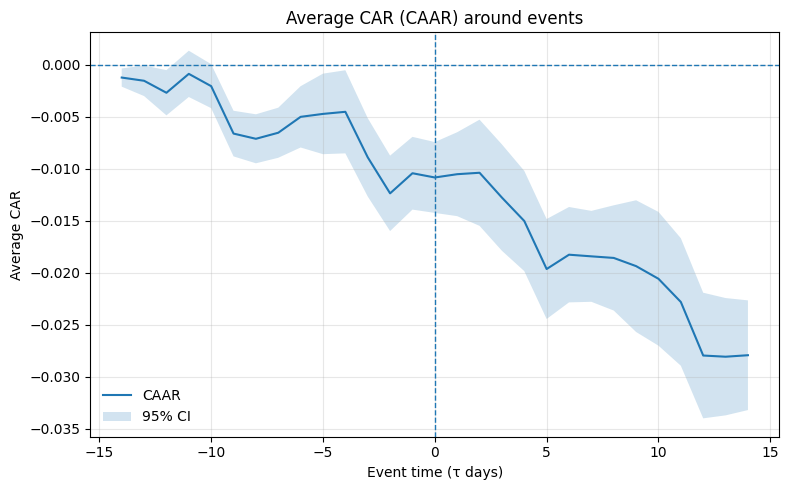

In [ ]:
# ========= 2) Plot Average CAR (CAAR) with 95% CI over event time =========
def plot_caar(car_paths: pd.DataFrame, title="Average CAR (CAAR) around events"):
    prof = (car_paths
            .groupby('tau', as_index=False)
            .agg(mean_CAAR=('CAR_tau','mean'),
                 std_CAAR=('CAR_tau','std'),
                 n=('CAR_tau','count')))
    prof['se'] = prof['std_CAAR'] / np.sqrt(prof['n'].replace(0, np.nan))
    prof['lo'] = prof['mean_CAAR'] - 1.96 * prof['se']
    prof['hi'] = prof['mean_CAAR'] + 1.96 * prof['se']

    plt.figure(figsize=(8,5))
    plt.plot(prof['tau'], prof['mean_CAAR'], label='CAAR')
    plt.fill_between(prof['tau'], prof['lo'], prof['hi'], alpha=0.2, label='95% CI')
    plt.axvline(0, linestyle='--', linewidth=1)
    plt.axhline(0, linestyle='--', linewidth=1)
    plt.title(title)
    plt.xlabel('Event time (τ days)')
    plt.ylabel('Average CAR')
    plt.legend(frameon=False)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_caar(car_paths)


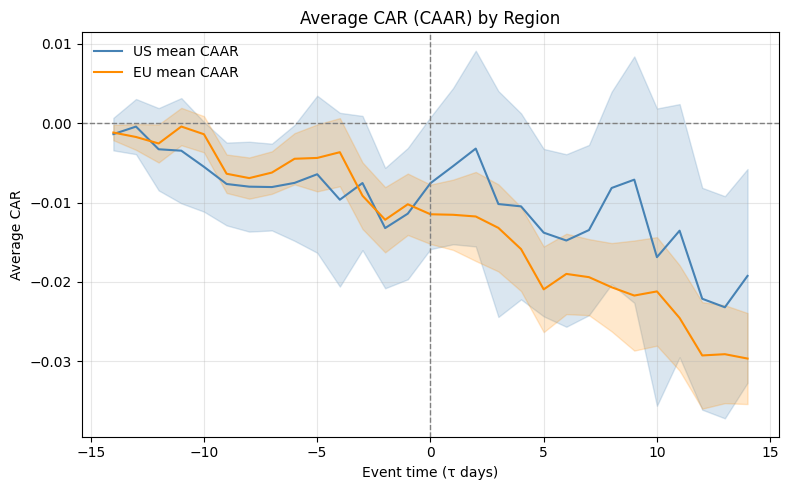

In [164]:
# ========= 3) (Optional) CAAR by region (US vs EU) =========

def plot_caar_by_region(car_paths: pd.DataFrame, title="Average CAR (CAAR) by Region"):
    plt.figure(figsize=(8,5))

    colors = {'US':'steelblue', 'EU':'darkorange'}
    for reg, color in colors.items():
        sub = car_paths[car_paths['region'] == reg]
        if sub.empty:
            continue

        prof = (sub
                .groupby('tau', as_index=False)
                .agg(mean_CAAR=('CAR_tau','mean'),
                     std_CAAR=('CAR_tau','std'),
                     n=('CAR_tau','count')))
        prof['se'] = prof['std_CAAR'] / np.sqrt(prof['n'].replace(0, np.nan))
        prof['lo'] = prof['mean_CAAR'] - 1.96 * prof['se']
        prof['hi'] = prof['mean_CAAR'] + 1.96 * prof['se']

        plt.plot(prof['tau'], prof['mean_CAAR'], color=color, label=f'{reg} mean CAAR')
        plt.fill_between(prof['tau'], prof['lo'], prof['hi'], color=color, alpha=0.2)

    plt.axvline(0, linestyle='--', color='gray', linewidth=1)
    plt.axhline(0, linestyle='--', color='gray', linewidth=1)
    plt.title(title)
    plt.xlabel('Event time (τ days)')
    plt.ylabel('Average CAR')
    plt.legend(frameon=False)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# ---- Run it
plot_caar_by_region(car_paths)
